# Playground Series S6E8 — Predicting Smartphone Addiction
## S6E8: why gaming_hours helps but adds nothing new（解説付き学習用コピー）

- **原著者**: GEORGY MAMARIN (georgymamarin)
- **元notebook**: https://www.kaggle.com/code/georgymamarin/s6e8-why-gaming-hours-helps-but-adds-nothing-new
- **評価**: 46 votes（Silver）・Version 32 of 33・2026-08-19時点で17時間前に更新
- **スコア**: LBスコアの掲示なし（**分析notebook**であり、順位を狙う提出ではない）

> ⚠️ これは**学習目的の解説付き写し**です。原著者のコードは変更していませんが、実行結果（outputs）は含んでいません。
> 各コードセルの直前に、日本語の「何をしているか（What）／なぜそうするのか（Why）」の解説セルを挿入しています。
> 原著の英語markdownはそのまま残してあります（そこに議論の本体があるため）。

---

### 今日この notebook を選んだ理由

このVaultではS6E8のnotebookをすでに15本扱っており、その**ほぼ全部がアンサンブル／スタッキング**でした。
今日は公開LB最上位（0.97113）のnotebookも確認しましたが、
**「コアの特徴量エンジニアリングと学習コードは非公開のまま、OOFと提出CSVだけ共有する」**という内容で、
実行時間20秒・コードはCSVを読んで書き出すだけ。学習価値がほぼゼロだったため見送りました。

代わりに選んだのがこの notebook です。LBスコアは掲げていませんが、
**「Kaggleでよくやる分析手法が、なぜ間違った結論を出すのか」を実測で示す**という内容で、
16本目のブレンドを読むより遥かに得るものがあります。

そして重要なのは、**この notebook 自体が「自分の主張を疑う」構造で書かれている**ことです。
セクション3で「gaming_hours は条件付けると無価値」と結論した直後、
セクション4で**その結論をアブレーションで検証し、部分的に自分を否定します**。
セクション13では「この測定が見られなかった範囲」を自分で列挙します。
Kaggleに限らず、データ分析の文章としてお手本になる態度です。

---

### 評価指標について

**タスク**: 1行 = 1人。12個の生活習慣の特徴量から、`addicted_label`（スマホ依存かどうか）を
予測する**二値分類**です。

**指標**: **ROC AUC**。

**なぜAUCなのか**: AUCは**ランキングだけを見る**指標で、
「依存している人のスコアが、していない人のスコアより高くなる確率」に等しい値です。
予測値が0.9なのか0.6なのかという**絶対値（キャリブレーション）は問われません**。
このnotebookのセクション8で、著者はOOF予測のヒストグラムとキャリブレーション曲線を
並べて描いたうえで「**2つのパネルは別のことを言っていて、リーダーボードに関係あるのは片方だけ**」
とはっきり書いています。分離の良さ（AUC）と確率の正確さ（キャリブレーション）は別物、という指摘です。

**このnotebookが指標に対して行っている最も重要な指摘**（セクション11）:

公開リーダーボードはテストセットの**20%（59,260行）**でしか採点されていません。
Hanley と McNeil (1982) の公式でAUC 0.971 のときの標準誤差を計算すると、
**上位10チームの隣り合うスコア差（9つのうち3つは差がちょうど0.00000）よりも、
採点の揺らぎのほうが大きい**ことが分かります。

つまり、**公開LBの1位と5位の差は、統計的には区別がついていない**。
「0.97113を0.97120にする」ための努力は、測定できない量を追いかけていることになります。
これは指標そのものの性質から導かれる、極めて実践的な結論です。

---

### この notebook の骨格（14セクション）

| § | 内容 |
|---|---|
| 1 | データ契約（dtype・欠損率・値域）の確認 |
| 2 | **単変量AUC**で特徴量をランク付けする、みんながやる最初の一手 |
| 3 | **条件付け**でそれを壊す：他の変数を固定すると `gaming_hours` のAUCは0.500になる |
| 4 | **アブレーション**が§3に反論する：それでもモデルに入れると少し上がる。理由は欠損補完 |
| 5 | 信号の出所を特定：**元データセット（mirror）のラベルは閾値ルールだった** |
| 6 | **スクリーンタイムが増えると依存確率が下がる領域**の発見と単調性制約 |
| 7 | 欠損パターンはターゲットについて何も語らない（adversarial validationで検証） |
| 8 | リークのないベースラインと提出 |
| 9 | **弱いベースラインは、特徴量の価値を過大評価させる** |
| 10 | ブレンドを分解する：74個のOOFを混ぜて得られる利得の実測 |
| 11 | **今日のリーダーボードは何を測っているのか**（採点の標準誤差） |
| 12 | シーズン6の過去7コンペのshake-up実績から予測を立てる |
| 13 | 設計上の選択と限界（自分の測定が見られなかった範囲） |
| 14 | 次に読むもの |

---


# S6E8: why gaming_hours helps but adds nothing new

**`gaming_hours` carries no signal about the target that survives conditioning. Inside twelve cells of
fixed screen time and social media it averages an AUC of 0.499 and cannot hold a sign. Added to the
model it is still worth +0.00322, against a seed-to-seed spread of 0.00007.** Both of those are measured
here, and they are not a contradiction. Working out why changes what is worth doing this month.

*By [Georgy Mamarin](https://www.kaggle.com/georgymamarin) · [Playground Series S6E8](https://www.kaggle.com/competitions/playground-series-s6e8)*

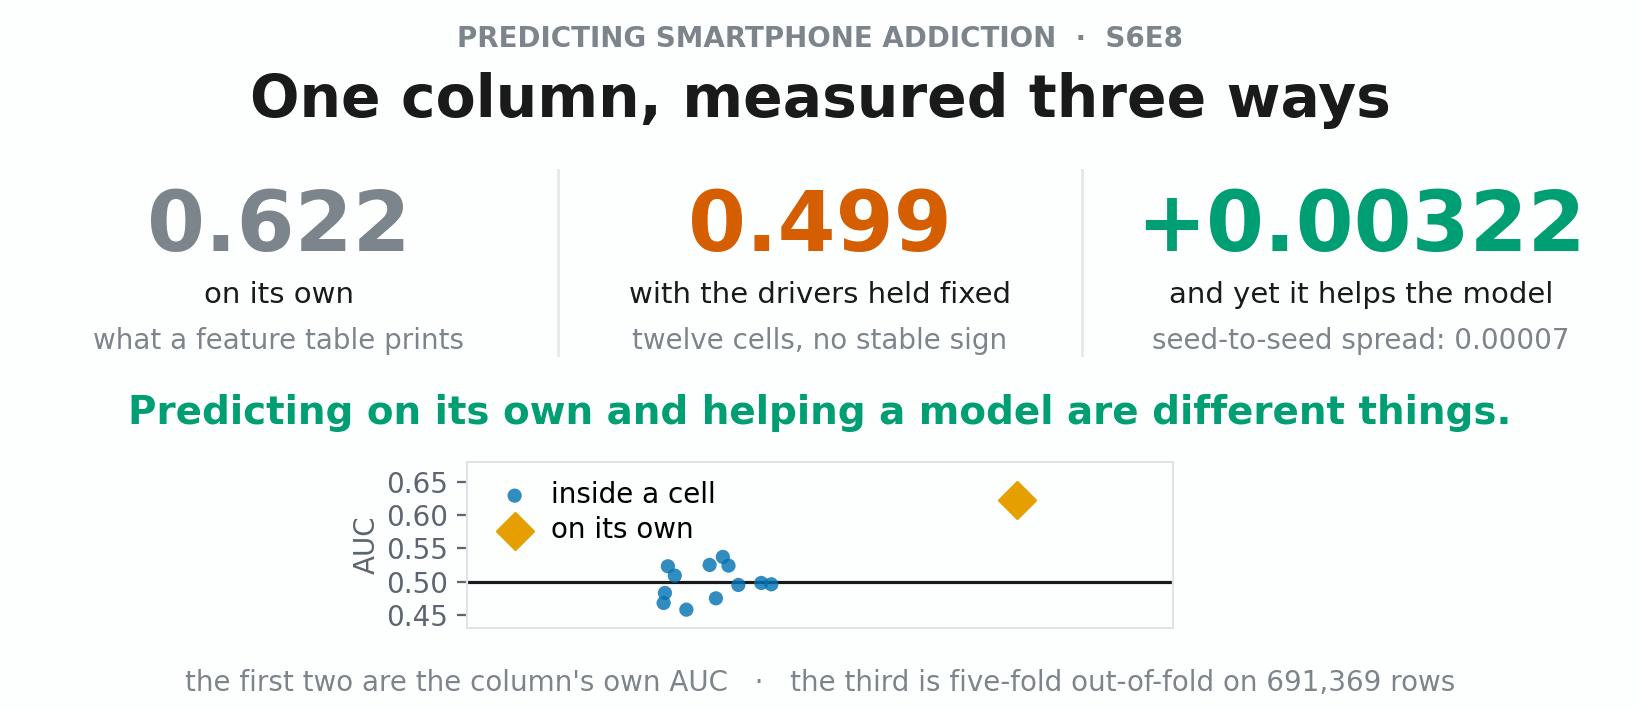

*Budget several hours end to end on a Kaggle CPU kernel; the two ablation sections, the reference
model in section 9 and the library work in sections 10 and 11 are where the time goes. Code and every
measurement script are in
[dmagog/kaggle-notebooks](https://github.com/dmagog/kaggle-notebooks).*

## What you'll take away

- **A control you can run on any tabular competition in four lines**, plus a worked example of it
  giving a right answer to a question I then asked wrongly. Single-feature AUC and conditional AUC
  disagree here about which columns to trust, and the ablation agrees with neither.
- **Why the marginal table is inflated in this dataset specifically.** The generator that made these
  rows built a correlation structure the source file does not have. It is measurable in both
  directions, and it lifts two columns into the middle of a ranking they have not earned.
- **One region where P(addicted) falls as screen time rises.** It survives a split-half check, and it
  makes a monotone constraint, a one-line and obviously reasonable idea, cost you score.
- **A drift alarm that you can safely ignore, with the measurement that proves it.** Adversarial
  validation separates train from test here. All of it sits in the missing-value patterns, and those
  say nothing about the target.
- **One engineered feature that actually pays**, in a competition where almost none do, and the reason
  it works where other arithmetic on the same columns does nothing.
- **A leak-free five-fold baseline** with out-of-fold predictions and a validated submission, so a
  fork starts from working plumbing instead of from scratch.
- **A two-submission test for whether a stranger's out-of-fold library leaks.** The CV-to-board
  offset here is stable enough (my three stacks on provable folds sit within about 0.00006 of one
  value) that a missing fraction of a promised CV gain shows up as a shortfall you can read off
  the board. Run live in section 10: the board paid about half the promised gap, and the missing
  half is itself a measurement.
- **What actually happened to the other seven boards of this season**, both halves of each attached
  and computed here rather than remembered: three erased their public top ten, and both rulers I
  tried to forecast with separate those seven and then disagree about this one, one of them only
  after a control I had first built wrongly.

## Contents

1. [The task and the data contract](#1.-The-task-and-the-data-contract)
2. [The signal atlas, the way everyone prints it](#2.-The-signal-atlas,-the-way-everyone-prints-it)
3. [The control that breaks it](#3.-The-control-that-breaks-it)
4. [The ablation disagrees with the control](#4.-The-ablation-disagrees-with-the-control)
   - [4c. Most of the other half, found by someone else](#4c.-Most-of-the-other-half,-found-by-someone-else)
5. [Where the extra signal came from](#5.-Where-the-extra-signal-came-from)
6. [The region where more screen time means less addiction](#6.-The-region-where-more-screen-time-means-less-addiction)
7. [Missingness tells you nothing about the target](#7.-Missingness-tells-you-nothing-about-the-target)
8. [A leak-free baseline and a submission](#8.-A-leak-free-baseline-and-a-submission)
9. [What a weak baseline does and does not inflate](#9.-What-a-weak-baseline-does-and-does-not-inflate)
10. [The blend, taken apart](#10.-The-blend,-taken-apart)
11. [What the leaderboard is measuring today](#11.-What-the-leaderboard-is-measuring-today)
12. [What seven finished boards say](#12.-What-seven-finished-boards-say)
13. [Design choices and limitations](#13.-Design-choices-and-limitations)
14. [What to read next](#14.-What-to-read-next)
15. [Credits](#Credits)

### 【解説】環境の固定と再現性の担保

**What**: 乱数シードを固定し、**使用した各ライブラリのバージョンを印字**しています。
さらに配色（Okabe-Ito）を定義しています。

**Why**:

- **なぜバージョンを印字するのか** — コメントに「Kaggleのベースイメージは更新され、
  結果が静かに変わるので、これらの数字を出した環境を固定しておく」と書かれています。
  LightGBMやscikit-learnはマイナーバージョンでデフォルト挙動が変わることがあり、
  半年後に同じnotebookを回して数字が違ったとき、**環境が変わったのかコードが悪いのか
  切り分けられなくなります**。1行のprintで防げるので、真似する価値が高い習慣です。

- **`seed_everything()`** は `random` / `numpy` / `PYTHONHASHSEED` の3つを揃えています。
  Pythonのハッシュシードまで固定するのは、辞書やsetの反復順が結果に影響する場合への対策です。

- **Okabe-Ito配色** は**色覚多様性に配慮した配色パレット**です。
  赤緑の区別がつきにくい人でも読める色の組み合わせが選ばれています。
  公開notebookで図を出すなら、これは知っておいて損のない配慮です。

> 🔰 **シード（seed）**とは乱数生成器の初期値のことです。同じシードなら同じ乱数列が出るので、
> 「実行するたびに結果が変わる」問題を防げます。ただし**シードを1つ固定して満足するのは危険**で、
> このnotebookは後半で**複数シードを回してばらつき（spread）を測る**という正しい使い方を見せます。


In [ ]:
import os, glob, random, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
warnings.filterwarnings("ignore")

SEED = 42
def seed_everything(s=SEED):
    random.seed(s); np.random.seed(s); os.environ["PYTHONHASHSEED"] = str(s)
seed_everything()

# The Kaggle base image moves and silently changes results, so pin what produced these numbers.
import lightgbm, sklearn, sys
print(f"python {sys.version.split()[0]}  numpy {np.__version__}  pandas {pd.__version__}  "
      f"lightgbm {lightgbm.__version__}  sklearn {sklearn.__version__}")

# Okabe-Ito. The three categorical slots carry identity and clear a colourblind-safety
# check (worst adjacent pair, deuteranopia and protanopia, is well past the usual floor);
# GREY is reserved for reference marks and never stands for a series. Labels wear ink,
# never the series colour, so identity always comes from the mark beside the text.
BLUE, ORANGE, GREEN, GREY = "#0072B2", "#E69F00", "#009E73", "#888888"
INK, MUTED = "#222222", "#555555"
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle

# A marker with a surface ring, so overlapping points stay separable.
def dot(ax, x, y, color, size=90, z=4):
    ax.scatter(x, y, s=size, color=color, zorder=z, edgecolor="white", linewidth=1.6)

# A legend handle. Legends live outside the data area; inside, they read as data.
def key(color, marker=True):
    return (Line2D([], [], marker="o", ls="", color=color, markersize=8,
                   markeredgecolor="white", markeredgewidth=1.4) if marker
            else Line2D([], [], color=color, lw=2.2))

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": .25,
                     "grid.linestyle": "-", "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

def find(pattern, *fallbacks):
    for hit in glob.glob(pattern, recursive=True):
        return hit
    for f in fallbacks:
        if os.path.exists(f):
            return f
    raise FileNotFoundError(pattern)

DATA = os.path.dirname(find("/kaggle/input/**/train.csv", "data/train.csv"))
train = pd.read_csv(os.path.join(DATA, "train.csv"))
test  = pd.read_csv(os.path.join(DATA, "test.csv"))

TARGET, ID = "addicted_label", "id"
NUM = ["age", "daily_screen_time_hours", "social_media_hours", "gaming_hours",
       "work_study_hours", "sleep_hours", "notifications_per_day",
       "app_opens_per_day", "weekend_screen_time"]
CAT = ["gender", "stress_level", "academic_work_impact"]
FEATURES = NUM + CAT
DST, SM = "daily_screen_time_hours", "social_media_hours"

print(f"train {train.shape}   test {test.shape}   positive rate {train[TARGET].mean():.4f}")

## 1. The task and the data contract

One row is one person. The target `addicted_label` is binary and the metric is **ROC AUC**, which
only cares about ranking: whether addicted people get higher scores than non-addicted ones. Nothing
below tunes a decision threshold, because the metric never looks at one.

Two facts to keep in mind for the rest of the notebook. The classes are unbalanced in the mild
direction, about seven positives to three negatives, which is comfortable for AUC. And every feature
column has missing values, between 4% and 20% of rows, which is unusual for this series and turns
out to matter less than it looks (section 7).

### 【解説】§1 データ契約（data contract）の確認

**What**: 各特徴量について dtype・欠損率・ユニーク数・最小/最大・カテゴリの水準を
1枚の表にまとめています。あわせて行数と `P(addicted)`（陽性率）を印字。

**Why**: モデリングの前に**データの形を全部見る**という基本動作です。
「data contract（データ契約）」という言い方が良くて、
「このデータはこういう形をしている、という取り決めを最初に確認する」という意識が現れています。

ここで確認すべきこと:
- **欠損率** — 後のセクションで「gaming_hours の価値の約半分は欠損の補完由来だった」という
  重要な発見に繋がります。最初に欠損率を見ておかないと、その発見に辿り着けません。
- **陽性率** — AUCの標準誤差の計算（§11）にこの値が必要になります。
- **distinct（ユニーク数）** — 「連続値のようで実は10段階しかない」といった罠を見つけられます。

> 🔰 `train[c].isna().mean()` は「欠損なら1、そうでなければ0」の平均なので**欠損率**になります。
> `.sum()` で件数、`.mean()` で割合。Pandasでよく使う書き方です。


In [ ]:
contract = pd.DataFrame({
    "dtype":   train[FEATURES].dtypes.astype(str),
    "missing %": (train[FEATURES].isna().mean() * 100).round(2),
    "distinct": train[FEATURES].nunique(),
    "min":     [train[c].min() if c in NUM else "" for c in FEATURES],
    "max":     [train[c].max() if c in NUM else "" for c in FEATURES],
    "levels":  ["" if c in NUM else ", ".join(map(str, sorted(train[c].dropna().unique()))) for c in FEATURES],
})
print(f"rows: train {len(train):,}   test {len(test):,}")
print(f"P(addicted) = {train[TARGET].mean():.4f}")
contract

## 2. The signal atlas, the way everyone prints it

The standard first move on a tabular competition is to score every feature on its own and rank them.
It is a good move. The table below does exactly that: for each column, the AUC it reaches by itself,
computed only on rows where that column is observed.

Read it the way you normally would, then hold on to the number for `gaming_hours` and
`work_study_hours`.

### 【解説】§2 単変量AUC ― 「みんながやる最初の一手」

**What**: 各特徴量を**それ単独で**使ったときのAUCを計算し、ランキングを作ります。

**Why（このセルの2つの工夫）**:

1. **`auc_sym()` = 方向を無視するAUC**
   ```python
   a = roc_auc_score(y, x)
   return max(a, 1 - a)
   ```
   AUCが0.3の特徴量は「弱い」のではなく「**逆向きに強い**」のです（符号を反転すれば0.7）。
   素直に `roc_auc_score` を使うと、逆相関の強い特徴量を「役立たず」と誤判定します。
   `max(a, 1-a)` で対称化するのは、探索段階では正しい処理です。

2. **カテゴリ変数は在サンプル（in-sample）のターゲット平均でエンコード**
   ```python
   enc = o[c].map(o.groupby(c)[TARGET].mean())
   ```
   コメントに「in-sample なので、これは**意図的に甘い（generous）**」と書いてあります。
   同じデータでターゲット平均を計算して同じデータを評価しているので、
   **リークによりAUCが本来より高く出ます**。著者はそれを承知のうえで
   「甘く見積もっても大したことがないなら、それは本当に弱い」という論法に使っています。
   **自分の測定のバイアスの向きを把握したうえで使う**のは、良い分析の条件です。

**この節の位置づけ**: この単変量AUCの表こそが、
notebook全体で**批判の対象になる「ありがちな分析」**です。§3以降でこれが壊されます。

> 🔰 **ROC AUC** = 陽性サンプルのスコアが陰性サンプルより高い確率。
> 0.5がランダム、1.0が完璧、0.0は完全に逆向き。


In [ ]:
from sklearn.metrics import roc_auc_score

def auc_sym(y, x):
    # AUC that ignores direction, so a feature ranking backwards is not called useless.
    a = roc_auc_score(y, x)
    return max(a, 1 - a)

rows = []
for c in NUM:
    o = train[[c, TARGET]].dropna()
    rows.append({"feature": c, "single-feature AUC": auc_sym(o[TARGET], o[c]), "n": len(o)})
for c in CAT:
    o = train[[c, TARGET]].dropna()
    # in-sample, so this is generous on purpose
    enc = o[c].map(o.groupby(c)[TARGET].mean())
    rows.append({"feature": c, "single-feature AUC": auc_sym(o[TARGET], enc), "n": len(o)})

atlas = (pd.DataFrame(rows).sort_values("single-feature AUC", ascending=False)
           .reset_index(drop=True))
atlas["single-feature AUC"] = atlas["single-feature AUC"].round(4)
atlas

### 【解説】§2の図 ― 3本が突出、2本が中間、7本がほぼ偶然

**What**: 単変量AUCを横棒グラフにします。`gaming_hours` と `work_study_hours` をオレンジで、
0.8以上を青で、それ以外をグレーで塗り分けています。

**Why**: `ax.barh(..., a["single-feature AUC"] - .5, left=.5, ...)` という書き方に注目してください。
**バーの起点を0ではなく0.5にしています**。AUCの0.5は「偶然」であり、
0から棒を伸ばすと「AUC 0.52の特徴量にも半分以上の棒がある」ように見えてしまいます。
**指標の意味のある基準点を、図の基準点に合わせる**という配慮です。

図の結論は3層構造です:
- **0.85〜0.89**: `daily_screen_time`, `weekend_screen_time`, `social_media_hours`（スマホ利用時間そのもの）
- **中間**: `gaming_hours`, `work_study_hours` — この2つが notebook の主役
- **0.50〜0.55**: 残り7本 — ほぼ偶然と区別がつかない


In [ ]:
fig, ax = plt.subplots(figsize=(8.2, 4.6))
a = atlas.sort_values("single-feature AUC")
colours = [ORANGE if f in ("gaming_hours", "work_study_hours") else
           (BLUE if v >= .8 else GREY) for f, v in zip(a.feature, a["single-feature AUC"])]
ax.barh(a.feature, a["single-feature AUC"] - .5, left=.5, color=colours)
ax.axvline(.5, color="k", lw=1)
ax.set_xlim(.5, .95); ax.set_xlabel("AUC of that column alone")
ax.set_title("Three columns far ahead, two in the middle, seven at chance")
for f, v in zip(a.feature, a["single-feature AUC"]):
    ax.text(v + .004, f, f"{v:.3f}", va="center", fontsize=10)
# Bottom right is empty for any data here: the short bars sit at the bottom.
# Placed in axes coordinates so it can never land on top of a bar or the axis.
from matplotlib.patches import Patch, Rectangle
# All three colours get a key: colour is never the only thing carrying the grouping,
# but an unexplained palette still makes the reader guess.
ax.legend(handles=[Patch(color=BLUE, label="far ahead"),
                   Patch(color=ORANGE, label="no conditional signal (section 3)"),
                   Patch(color=GREY, label="at chance")],
          loc="lower right", frameon=False, fontsize=10)
fig.tight_layout(); plt.show()

Daily screen time, weekend screen time and social media hours sit between 0.85 and 0.89, no surprise
for a dataset about phone use, and seven more sit between 0.50 and 0.55. (Every column clears 0.50
here because the AUC is symmetrised, so a column that ranks backwards is not reported as useless;
0.50 is the floor, not a pass mark.)

The interesting pair is `work_study_hours` and `gaming_hours`, sitting in the middle of the table at
around 0.65 and 0.62. Those are not large numbers, but they are not noise-level either, and a feature
zoo built on this table would happily use both.

## 3. The control that breaks it

A single-feature AUC answers: *if this column were all I had, how well could I rank?* That is rarely
the question you care about. The question you care about is: *given what the strong columns already
tell me, does this one add anything?*

The two answers can differ, and the way to find out is to hold the strong columns fixed. Four lines,
on any tabular problem:

    for lo_a, hi_a in bands_a:            # a grid over the columns you trust
        for lo_b, hi_b in bands_b:
            cell = df[df[a].between(lo_a, hi_a) & df[b].between(lo_b, hi_b)]
            print(len(cell), roc_auc_score(cell[target], cell[suspect]))

Below, every cell fixes daily screen time to a one-hour band and social media hours to a half-hour
band, then measures the remaining columns inside that cell. If a column carries its own signal, it
keeps it here. If it was only riding along on the strong columns, it drops to 0.50.

One detail matters: the AUC below is **signed**, not symmetrised. Above 0.50 means more of the column
goes with being addicted; below 0.50 means the opposite. A column with real signal keeps the same
side across cells. A column with none wanders.

### 【解説】§3 「条件付け」という反証 ― この notebook の中核アイデア

**What**: `daily_screen_time` と `social_media_hours` の値で**データを細かいセルに区切り**、
**セルの中だけで** `gaming_hours` のAUCを測り直します。
（daily を4〜8時間で4区間、social を1.0〜2.5時間で3区間、計12セル。各500行以上のセルだけ採用）

**Why（ここが最重要）**:

単変量AUCが答えている問いは
> 「この列**しか無かったら**、どれくらいうまく順位付けできるか？」

ですが、実際に知りたいのは
> 「他の列が**すでにある**として、この列を足すと何か**新しいこと**が分かるか？」

です。この2つは全く違う問いです。
`gaming_hours` が単独で0.62のAUCを出すのは、
**`gaming_hours` が長い人はスクリーンタイムも長い**からで、
本当に効いている変数（スクリーンタイム）の影を見ているだけかもしれません。

**条件付け（conditioning）**とは、その本当に効いている変数を**固定してしまう**ことです。
「daily が5〜6時間で、social が1.5〜2.0時間の人たち」の中だけを見れば、
その集団内では daily も social もほぼ一定なので、
そこで `gaming_hours` にまだ予測力が残っていれば**それは本物の追加情報**です。

結果は次のセルの図で示されますが、**12セルの平均でほぼちょうど0.500**、
つまり `gaming_hours` は**追加情報をまったく持っていない**、という結論になります。

> 🔰 これは統計学でいう**交絡（confounding）**の話です。
> AとBに相関があっても、両方に影響する第三の変数Cがあるだけかもしれない。
> Cを固定して（条件付けて）もなおAとBに関係が残るかを見る、というのが標準的な検証手続きです。
>
> 🔰 なぜ `len(c) < 500` のセルを捨てるのか：サンプルが少ないセルではAUCの推定が
> 不安定になり、ノイズを結論と勘違いするからです。**測定の精度が足りないものは使わない**。


In [ ]:
obs = train[[DST, SM, "gaming_hours", "work_study_hours", "sleep_hours",
             "app_opens_per_day", TARGET]].dropna()

cells_out = []
for lo_d in [4, 5, 6, 7]:
    for lo_s, hi_s in [(1.0, 1.5), (1.5, 2.0), (2.0, 2.5)]:
        c = obs[(obs[DST] > lo_d) & (obs[DST] <= lo_d + 1) &
                (obs[SM] > lo_s) & (obs[SM] <= hi_s)]
        y = c[TARGET].to_numpy()
        if len(c) < 500 or y.min() == y.max():
            continue
        cells_out.append({
            "daily": f"({lo_d}, {lo_d+1}]", "social": f"({lo_s}, {hi_s}]", "n": len(c),
            "P(y=1)": round(y.mean(), 3),
            "gaming": round(roc_auc_score(y, c.gaming_hours), 3),
            "work_study": round(roc_auc_score(y, c.work_study_hours), 3),
            "sleep": round(roc_auc_score(y, c.sleep_hours), 3),
            "app_opens": round(roc_auc_score(y, c.app_opens_per_day), 3),
        })
cond = pd.DataFrame(cells_out)
print(f"cells: {len(cond)}   rows covered: {cond.n.sum():,}")
print("\nmean signed AUC inside a cell (0.500 = no signal):")
print(cond[["gaming", "work_study", "sleep", "app_opens"]].mean().round(3).to_string())
print("\ncells below 0.500, i.e. the column points the other way:")
print((cond[["gaming", "work_study", "sleep", "app_opens"]] < .5).sum().to_string()
      + f"   out of {len(cond)}")
cond

### 【解説】§3の図 ― 単変量AUC（ダイヤ）と条件付きAUC（点群）の対比

**What**: 4つの特徴量それぞれについて、**オレンジのダイヤ = 単変量AUC**、
**青い点の群れ = 12セル内それぞれのAUC** を同じ縦軸に並べています。

**Why**: この図の設計が非常に上手いです。
「単変量では0.62、条件付けると0.50」という主張を、
**同じ縦軸上で1つのダイヤと12個の点として見せる**ことで、
ギャップの大きさとばらつきの両方が一目で分かります。

`np.full(len(cond), i) + np.random.uniform(-.13, .13, len(cond))` は
**ジッター（jitter）**といって、点が縦に重なって見えなくなるのを防ぐため、
横方向にわずかなランダムずれを加えるテクニックです。散布図の定番の工夫です。

図の読み取り: `gaming_hours` も `work_study_hours` も、
条件付きAUCの点群が**0.500の線をまたいで散らばり、どちら側にいるかすら決められない**。
これが「no signal that survives conditioning（条件付けを生き延びる信号がない）」という
タイトルの主張の根拠です。


In [ ]:
fig, ax = plt.subplots(figsize=(8.2, 4.2))
FULL = {"gaming": "gaming_hours", "work_study": "work_study_hours",
        "sleep": "sleep_hours", "app_opens": "app_opens_per_day"}
cols = list(FULL)
marg = {k: float(atlas.loc[atlas.feature == v, "single-feature AUC"].iloc[0])
        for k, v in FULL.items()}
for i, c in enumerate(cols):
    ax.scatter(np.full(len(cond), i) + np.random.uniform(-.13, .13, len(cond)), cond[c],
               s=34, color=BLUE, alpha=.75, zorder=3, label="inside a cell" if i == 0 else None)
    ax.scatter([i], [marg[c]], s=150, marker="D", color=ORANGE, zorder=4,
               label="on its own (section 2)" if i == 0 else None)
ax.axhline(.5, color="k", lw=1.2)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols)
ax.set_ylabel("AUC"); ax.set_ylim(.42, .72)
ax.set_title("Fix daily screen time and social media, and the middle of the table collapses")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout(); plt.show()

`gaming_hours` averages almost exactly 0.500 across the cells and cannot decide which side of 0.500 it
belongs on. `work_study_hours` does the same. Both looked informative in section 2, and neither
survives conditioning.

The more interesting half of the table is the other two columns. `sleep_hours` and `app_opens_per_day`
sit just below the pair in the section 2 ranking, at the top of the block it calls chance, and they are
the only two that hold the same side of 0.500 in every single cell. The effect is small, but it is consistent in a way the two larger numbers
are not.

So the marginal table does not merely inflate. **It reorders.** It puts `work_study_hours` at 0.65,
well above `sleep_hours` at 0.53, and conditioning reverses that: the column ranked higher is the one
that turns out to be noise. If you were picking features to build on from the section 2 ranking, it
would have pointed you at the wrong end of its own list.

A fair objection: the cells are one hour wide in daily screen time, so some variation is left inside
them, and leftover variation could still be doing the work. Note which way that cuts. Residual
confounding inside a cell would *manufacture* apparent signal, not destroy it. Finding 0.500 despite
it is the conservative outcome, not the fragile one. The next section removes the objection entirely
by putting the question to a model.

## 4. The ablation disagrees with the control

Conditioning is an argument. The metric is the judge. This section gives a model a set of columns,
takes some away, and reports what the competition metric does. Every setting inside one seed shares its
folds, so the comparisons are paired; the fold split is redrawn for each new seed, so the spread below
already contains resplit noise as well as model noise. Three seeds, because one split is not a measurement.

Two comparisons carry the section. Adding `gaming_hours` and `work_study_hours` on top of the three
screen-time columns is the direct test of section 3. Dropping those three and keeping the other nine
shows what the rest of the table is worth on its own.

### 【解説】§4 アブレーション ― 条件付けの結論に、モデル自身が反論する

**What**: LightGBMに与える特徴量セットを5通り変えて、5-fold のOOF AUCを比較します。

| セット | 内容 |
|---|---|
| the three screen columns | daily / social / weekend の3本だけ |
| three + gaming | それに gaming_hours を追加 |
| three + gaming + work | さらに work_study_hours を追加 |
| all twelve | 全12特徴量 |
| all twelve minus the three | 3本を抜いた9本 |

**Why（この節が notebook の誠実さを示す）**:

§3は「gaming_hours は条件付きでは無価値」と結論しました。
普通ならそこで終わりですが、著者は**その結論をモデルで検証しにいきます**。
そして結果は§3の予測と**食い違います**。gaming_hours を足すとAUCは（わずかに）上がるのです。

markdownには「Conditioning is an argument. The metric is the judge.
（条件付けは"議論"にすぎない。判定を下すのは指標だ）」と書かれています。
**きれいな理屈より、実測を上に置く**という姿勢です。

**アブレーション（ablation）**とは、構成要素を1つずつ取り除いて性能変化を見る実験手法です。
機械学習の論文では標準的な検証方法で、
「この工夫が本当に効いているのか」を答える唯一まともな方法です。

**この設計の重要な点**: 各セットを**複数シードで回して mean と spread（ばらつき）を出す**こと。
1シードだけの差分は、シード間のばらつきに埋もれている可能性があります。
**差分は必ずノイズの大きさと比較して読む**、という原則がここで実装されています。

> 🔰 **OOF (Out-Of-Fold) 予測**とは、交差検証で「そのfoldの学習に使っていないデータ」に対する予測のこと。
> 学習に使ったデータで評価すると必ず甘くなるので、OOFで評価するのが基本です。


In [ ]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold

THREE = [DST, SM, "weekend_screen_time"]
SETS = {
    "the three screen columns":   THREE,
    "three + gaming":             THREE + ["gaming_hours"],
    "three + gaming + work":      THREE + ["gaming_hours", "work_study_hours"],
    "all twelve":                 FEATURES,
    "all twelve minus the three": [c for c in FEATURES if c not in THREE],
}
PARAMS = dict(objective="binary", metric="auc", learning_rate=.05, num_leaves=63,
              min_data_in_leaf=200, feature_fraction=.9, bagging_fraction=.9,
              bagging_freq=1, verbosity=-1)
ROUNDS, SEEDS = 400, [0, 1, 2]

Xall = train[FEATURES].copy()
for c in CAT:
    Xall[c] = Xall[c].astype("category")
y = train[TARGET].to_numpy()

def oof_auc(feats, seed):
    skf = StratifiedKFold(5, shuffle=True, random_state=seed)
    oof = np.zeros(len(y))
    for tr_i, va_i in skf.split(Xall, y):
        ds = lgb.Dataset(Xall.iloc[tr_i][feats], y[tr_i])
        m = lgb.train({**PARAMS, "seed": seed}, ds, num_boost_round=ROUNDS)
        oof[va_i] = m.predict(Xall.iloc[va_i][feats])
    return roc_auc_score(y, oof)

abl = {name: [oof_auc(f, s) for s in SEEDS] for name, f in SETS.items()}
tab = pd.DataFrame(abl, index=[f"seed {s}" for s in SEEDS]).T
seed_cols = list(tab.columns)
tab["mean"]     = tab[seed_cols].mean(axis=1)
tab["spread"]   = tab[seed_cols].max(axis=1) - tab[seed_cols].min(axis=1)
tab["features"] = [len(f) for f in SETS.values()]
tab.round(5)

### 【解説】§4 結果の読み方 ― 差分は必ず「ばらつき」と比べる

**What**: 「3本だけ」を基準にした各セットの差分を印字し、
さらに `gaming_hours` を足した効果とシード間ばらつきの比を出します。

**Why**: ここに書かれている
「`gaming_hours` は単体で **+0.000XX** の価値、対してシード間のばらつきは **0.000YY**」
という**比較の形式**が、この notebook が繰り返し使う型です。

**改善幅そのものには意味がない。ノイズとの比にしか意味がない。**

Kaggleで「特徴量を1つ足したらCVが0.0003上がった！」という報告をよく見ますが、
シードを変えただけで0.0005動くなら、その0.0003は**何も言っていません**。
このセルはその比較を、コメント（「タイトルと冒頭カードが引用する2つの数字を、
2回の実行ではなく1回の実行から出すためにここで印字する」）まで含めて丁寧にやっています。

> 🔰 コメントの意図：「冒頭に書いた数字」と「ここで計算した数字」が別々の実行結果だと、
> 微妙にズレて読者を混乱させます。**引用する数字は必ず同じ実行から出す**という配慮です。


In [ ]:
base = tab.loc["the three screen columns", "mean"]
delta = (tab["mean"] - base).round(5).rename("vs the three screen columns")
print(f"reference: the three screen columns = {base:.5f} OOF AUC\n")
display(delta.to_frame("vs the three screen columns").round(5))

# The two numbers the title block and the card at the top quote, printed here so both halves
# of that ratio come out of this run rather than out of two.
HEAD = ["the three screen columns", "three + gaming"]
print(f"\nheadline: gaming_hours alone is worth {tab.loc[HEAD[1], 'mean'] - base:+.5f}, "
      f"against a seed-to-seed spread of {tab.loc[HEAD, 'spread'].max():.5f}")
print(f"seed-to-seed spread at its widest over all {len(tab)} settings: {tab['spread'].max():.5f}")

Read the deltas against the spread column, and the section does not say what section 3 predicted it
would say.

`gaming_hours` and `work_study_hours` carry no signal you can find by conditioning, and adding them
is worth many times the seed-to-seed noise of the same model. Both measurements are correct. I wrote
the first one down expecting it to settle the second, and it does not.

### 4b. The two answers are to different questions

A column can matter to a model without predicting the target. The clue is in section 1: daily screen
time is missing on about 14% of rows and social media hours on about 19%. On roughly a quarter of the
data, the model does not have the columns that decide the label.

Section 5 shows a budget constraint in this data. Daily screen time is never less than social
plus gaming plus work/study, with zero exceptions in over four hundred thousand rows. That makes
`gaming_hours` and `work_study_hours` informative about *the missing values of the columns that do
predict*, without being informative about the label itself.

If that is the mechanism, the gain has nothing left to do on rows where both drivers are present.
Same schedule and the same seeds; the folds are redrawn because the row set changes.

### 【解説】§4b 欠損の補完という「隠れた」貢献

**What**: `daily_screen_time` と `social_media_hours` の**両方が観測されている行だけ**に絞り、
同じアブレーションをやり直します。

**Why（見事な切り分け）**:

`gaming_hours` が価値を持つ経路は2つ考えられます。

1. **本当に追加情報を持っている** → §3で否定された
2. **主要な変数が欠損している行で、その代役になっている** → まだ検証されていない

2番目を検証するには、**主要変数が欠損している行を除いて**測り直せばいい。
それがこのセルです。結果、`gaming_hours` と `work_study_hours` の価値の
**約46%が消えます**。つまり半分近くは「代役」としての価値だった。

これは実務的に非常に重要な発見です。もし欠損補完のためだけに効いているなら、
**より良い補完手法を入れれば、その特徴量は要らなくなる**かもしれません。
「効いている」で止めず「**なぜ**効いているか」まで踏み込むと、次の一手が見えます。


In [ ]:
both = train[DST].notna() & train[SM].notna()
print(f"rows with both drivers observed: {both.sum():,} of {len(train):,} "
      f"({both.mean():.1%})\n")

sub_train = train[both].reset_index(drop=True)
Xsub = sub_train[FEATURES].copy()
for c in CAT:
    Xsub[c] = Xsub[c].astype("category")
ysub = sub_train[TARGET].to_numpy()

def oof_auc_on(X, yy, feats, seed):
    skf = StratifiedKFold(5, shuffle=True, random_state=seed)
    p = np.zeros(len(yy))
    for tr_i, va_i in skf.split(X, yy):
        m = lgb.train({**PARAMS, "seed": seed},
                      lgb.Dataset(X.iloc[tr_i][feats], yy[tr_i]), num_boost_round=ROUNDS)
        p[va_i] = m.predict(X.iloc[va_i][feats])
    return roc_auc_score(yy, p)

pair = ["the three screen columns", "three + gaming + work"]
rows = []
for label, (X_, y_) in [("all rows", (Xall, y)), ("both drivers observed", (Xsub, ysub))]:
    sc = {k: np.mean([oof_auc_on(X_, y_, SETS[k], s) for s in SEEDS[:2]]) for k in pair}
    rows.append({"rows used": label, **{k: round(v, 5) for k, v in sc.items()},
                 "gain from gaming + work": round(sc[pair[1]] - sc[pair[0]], 5)})
pd.DataFrame(rows).set_index("rows used")

About half the gain is imputation. Removing the rows with a missing driver removes roughly 46% of what
`gaming_hours` and `work_study_hours` were worth, which is a large share to attribute to one mechanism
and nowhere near all of it.

I am not going to round that up into a clean story. **When this notebook first went up, nothing in it
explained the remaining half.** Section 4c is what happened next. Either way the honest reading of
section 3 has to shrink to fit: the twelve cells there cover 17% of the
rows where both drivers are observed, inside a window running from 4 to 8 hours of daily screen time
and 1 to 2.5 of social media. Outside that window the control never looked. A gradient booster looks
everywhere, and it is finding something there that twelve cells in the middle of the distribution
cannot see.

So the defensible claims are narrower than the ones I set out to make. Inside the region section 3
covers the marginal table has the ordering backwards; both columns are still worth keeping, and about
half of why is that they reconstruct drivers the generator left recoverable by exact arithmetic.
**Reconstruction is a lever.** I also wrote here that feature engineering on these columns probably was
not one, and section 4c is why that half of the sentence did not survive the week.

If you can account for the other half, I would like to see it, and I will add it here with credit.

### 4c. Most of the other half, found by someone else

Two days after that paragraph went up, [Dariush Afshar](https://www.kaggle.com/dariushafshar) answered
a question from [Muhammad Faheem](https://www.kaggle.com/muhammadf4h33m) in
[this thread](https://www.kaggle.com/competitions/playground-series-s6e8/discussion/732223) with a
feature I had not tried:

    other_screen = daily_screen_time - (social_media + gaming + work_study)

The screen time a person spends on nothing the dataset names. It rests on the budget constraint from
section 5, so it only exists where all four columns do.

This is what my section 3 control could not have found, and the reason is structural rather than bad
luck. That control measures one column at a time inside a cell. The residual is a function of three
columns at once, and no amount of measuring `gaming_hours` on its own will surface it. A control that
holds the strong features fixed tells you whether a column carries signal alone. It says nothing about
what the column carries in combination.

The measurement below takes the feature three ways: on its own, as a replacement for the two columns whose
gain section 4b could not explain, and added to the full model.

### 【解説】§4c 残差特徴量 ― 制約から作る特徴量

**What**: 新しい特徴量を1つ作ります。
```python
resid_all = train[DST] - (train[SM] + train["gaming_hours"] + train["work_study_hours"])
```
「1日の総スクリーンタイム − （SNS + ゲーム + 仕事/勉強）」= **その他の用途に使った時間**。

**Why（この notebook で最も実用的なアイデア）**:

このデータには**時間配分という物理的な制約**があります。
「daily_screen_time は、その内訳の合計以上でなければおかしい」。
この制約から作った残差は、単なる引き算なのに**単独でAUC約0.76**を出します。
これは§2の表で**4位相当**、`gaming_hours` 単独（0.62）よりずっと上です。

なぜ強いのか。`gaming_hours` 単体は「ゲームを何時間したか」しか言いませんが、
残差は「**総時間のうち、説明のつかない部分がどれだけあるか**」を表します。
依存の指標としては後者のほうが直接的です。

**そして§13で著者はこう自己批判します**：
「§3の条件付けは**組み合わせに対して盲目**であり、§4cはそれが最も重要な特徴量を
見逃した実例である」。§3の手法は個々の変数を1つずつ条件付けて見るので、
**複数の変数の組み合わせから生まれる情報**は原理的に検出できません。

**教訓**: ドメインの制約（時間は足して24時間、金額は合計が総額、など）から
作られる特徴量は、単なる交互作用より遥かに強いことがある。
そしてそれは、単変量の分析では**絶対に見つからない**。

> 🔰 `print(f"rows where it comes out negative: ...")` で
> **残差が負になる行数**を数えているのを見逃さないでください。
> 負ということは「内訳の合計が総時間を超えている」= データが物理的におかしい行です。
> 新しい特徴量を作ったら、**まず物理的にありえない値が出ていないか確認する**。


In [ ]:
RESID = "other_screen"
resid_all = train[DST] - (train[SM] + train["gaming_hours"] + train["work_study_hours"])
ok = resid_all.notna()
print(f"computable on {ok.sum():,} of {len(train):,} rows ({ok.mean():.1%})")
print(f"rows where it comes out negative: {int((resid_all < -1e-9).sum())}")
print(f"standalone AUC where it exists:   "
      f"{roc_auc_score(train[TARGET][ok], resid_all[ok]):.4f}\n")

Xr = Xall.copy(); Xr[RESID] = resid_all
Xsub_r = Xsub.copy(); Xsub_r[RESID] = resid_all[both].to_numpy()
GW = ["gaming_hours", "work_study_hours"]

diag = []
for label, feats in [("three screen columns", THREE),
                     ("three + gaming + work", THREE + GW),
                     ("three + residual", THREE + [RESID])]:
    diag.append({"features on complete rows": label,
                 "OOF AUC": np.mean([oof_auc_on(Xsub_r, ysub, feats, s)
                            for s in SEEDS[:2]])})
diag = pd.DataFrame(diag).set_index("features on complete rows")
diag["vs three"] = diag["OOF AUC"] - diag["OOF AUC"].iloc[0]
share = diag["vs three"].iloc[2] / diag["vs three"].iloc[1]
print(diag.round(5).to_string())
print(f"\nthe residual alone recovers {share:.0%} of what gaming + work_study "
      f"are worth here\n")

full = [oof_auc_on(Xr, y, FEATURES, s) for s in SEEDS]
plus = [oof_auc_on(Xr, y, FEATURES + [RESID], s) for s in SEEDS]
gain = np.array(plus) - np.array(full)
print(f"all twelve             {np.mean(full):.5f}   spread {max(full)-min(full):.5f}")
print(f"all twelve + residual  {np.mean(plus):.5f}   spread {max(plus)-min(plus):.5f}")
print(f"paired gain per seed   {np.round(gain, 5).tolist()}")
print(f"mean gain              {gain.mean():+.5f}")

On its own the residual lands at about 0.76. That puts it fourth in the section 2 table, behind the
three screen-time columns and ahead of everything else, including `gaming_hours` and `work_study_hours`
at 0.62 and 0.65. Two of its four inputs are the columns section 3 showed carry nothing alone. Combining
them with the column that carries the most produces something that outranks either of them.

So the open question from section 4b is now mostly closed, and not by me. On the rows where both
drivers are present, the residual on its own recovers about two thirds of what `gaming_hours` and
`work_study_hours` were worth. They were never carrying signal about addiction. They were carrying
one arithmetic fact about a column that does.

A third of that gain is still unaccounted for, and I would rather leave that written down than round
it away.

The practical half matters more than the diagnostic half. Added to the full twelve-column model the
residual is worth roughly ten times the seed-to-seed spread, and it moves the same direction on every
seed. That is a real feature in a competition where most engineered features do nothing, which makes
it a direct answer to the question Muhammad Faheem asked in that thread: yes, feature engineering can
move this dataset, but not by combining columns the trees can already split on. It moves when a
feature encodes something about how the data was made.

Credit where it belongs. The constraint underneath this was published first by
ryota517, whose notebook has since been removed from Kaggle. Turning it
into a feature and measuring it is Dariush Afshar's. What is mine is the check that it explains the
hole section 4b left, and the numbers above.

## 5. Where the extra signal came from

If `gaming_hours` carries no conditional signal, why does it reach 0.62 on its own? Something has to
correlate it with the columns that do carry signal. This section finds that something.

The data page says these rows were inspired by a Smartphone Addiction Prediction Dataset. The dataset
it links to is not publicly readable. A separate public dataset,
[Smartphone Usage & Addiction Prediction](https://www.kaggle.com/datasets/jayjoshi37/smartphone-usage-and-addiction-prediction), carries the same twelve predictors and the
same target plus three extra columns.

**I cannot prove it is the source**, and I am not going to write as though I can. Two independent
uploads of that file are byte-identical, which tells you they came from a common ancestor, not that
the ancestor is this competition's. ryota517 reached the same fork in the road first and
called the file a *candidate mirror*; that is the right name and I use it here. Everything below is
a comparison between two files, and the conclusion is re-checked on competition data alone before it
is used for anything.

### 【解説】§5 元データセット（mirror）の探索

**What**: `Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv` という
**元になった実データセット**を読み込み、コンペデータには無い列を印字します。

**Why**: Playground Series のデータは、**実在の公開データセットを元に生成モデルで合成**されています。
Kaggleは元データセットを公式に明示することが多く、参加者はそれを追加データとして使えます。

しかしこの notebook の使い方はもっと踏み込んでいます。
**「元データを見て、ラベルがどう作られたかを逆算する」**のです。
これが次のセルの内容で、この notebook で最も鮮やかな部分です。

> 🔰 なぜ `find(...)` という関数でファイルを探しているのか：
> Kaggleのデータセットのマウント先ディレクトリ名は、添付方法によって変わります。
> パスをハードコードせず**ファイル名でglob検索する**のは、フォークされても動く notebook の書き方です。


In [ ]:
MIRROR = find("/kaggle/input/**/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv",
              "mirror/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
mirror = pd.read_csv(MIRROR)
print(f"candidate mirror: {mirror.shape}, P(addicted) = {mirror[TARGET].mean():.4f}")
print(f"columns it has that the competition does not: "
      f"{sorted(set(mirror.columns) - set(train.columns))}")

### 5a. The mirror's label is a rule

Before comparing correlations, look at how the label behaves in the mirror. It is not a graded score
with a fuzzy boundary. It is a threshold on two columns, with a coin flip in between.

### 【解説】§5a 「ラベルはルールだった」― 決定的な発見

**What**: 元データセットで、`daily > 8 または social > 4` という条件を満たす行と、
`daily <= 6 かつ social <= 4` の行で、それぞれ `P(addicted)` を計算します。

**Why（結果が衝撃的）**:

- 第1の条件に当てはまる行 → **例外なく全て addicted = 1**
- 第2の条件に当てはまる行 → **例外なく全て addicted = 0**
- その中間の帯（6 < daily <= 8）→ **約14%（1,025行）が、どの列でも予測できないコイン投げ**

つまり元データセットの `addicted_label` は、**人手のアノテーションでも実測でもなく、
2つの閾値ルールで機械的に作られたラベル**だったのです。
「rows breaking the first clause: 0」「rows breaking the second: 0」という
**違反ゼロ**の出力がその証拠です。

**なぜこれが重要なのか**:

1. **AUCの理論的な上限が見える**。中間帯の14%が本当にランダムなら、
   どんなモデルもその部分は当てられません。**上限は0.98前後**という計算が立ちます。
   実際の公開LB最上位が0.971であることと整合します。
   → **「あと0.001上げる」努力に意味があるかを判断する材料**になります。

2. **どこにモデリングの余地があるかが分かる**。閾値の外側は簡単（ルールで決まる）。
   勝負は**中間帯**だけ。ならば中間帯に絞った分析・モデルに時間を使うべきです。

3. **合成データの限界が見える**。生成モデルはこの閾値構造をある程度引き継ぐので、
   コンペデータでも同じ構造が（緩んだ形で）残っているはずです。次のセルで検証されます。

> 🔰 これは「**リークではなく、データ生成過程の理解**」です。
> テストのラベルを直接見ているわけではなく、公開されている元データの構造を調べているだけなので、
> ルール違反ではありません。むしろKaggleで上位に行く人が必ずやっている作業です。


In [ ]:
ym = mirror[TARGET].to_numpy()
dm, sm_ = mirror[DST].to_numpy(), mirror[SM].to_numpy()
fires = (dm > 8) | (sm_ > 4)
low   = (dm <= 6) & ~fires
band  = (dm > 6) & ~fires

for label, mask in [("daily > 8 or social > 4", fires),
                    ("daily <= 6 and social <= 4", low),
                    ("6 < daily <= 8, social <= 4", band)]:
    print(f"P(y=1 | {label:<28}) = {ym[mask].mean():.4f}   n = {mask.sum():,}")

print(f"\nrows breaking the first clause: {int(((ym == 0) & fires).sum())}")
print(f"rows breaking the second:       {int(((ym == 1) & low).sum())}")

inband = mirror[band]
corr = (inband[NUM].corrwith(pd.Series(ym[band], index=inband.index))
        .abs().sort_values(ascending=False))
print(f"\ninside the band, largest |correlation| with the label: "
      f"{corr.index[0]} at {corr.iloc[0]:.3f}")

Two clauses with no exceptions in either direction, and 1,025 rows in between, about 14% of the file,
where the label is a coin flip that no column predicts. The thresholds are not perfectly crisp. A handful of rows sit
exactly on 8.00 and 4.00 and split both ways, which looks like a continuous quantity rounded to two
decimals rather than a hard cut. The shape is still unmistakable.

In the mirror, then: two of the twelve shared predictors decide the label and the other ten are decorative.

### 5b. What the generator changed

Now the comparison. Kaggle's synthetic data is produced by a model trained on the source, and models
do not copy, they approximate. Two things changed, and the second one explains section 2.

### 【解説】§5b ルールはコンペデータにどこまで転移したか

**What**: 元データで見つけた閾値ルール（daily > 8 or social > 4）を、
**コンペの学習データに当てはめて** `P(y=1)` を測り直し、両者を並べて比較します。
あわせて「daily >= social + gaming + work」という**時間配分の制約**がどれだけ守られているかも確認。

**Why**: 元データで見つけた構造が、合成データにどれだけ残っているかを測っています。

結果として（次のセルの図と合わせて）分かるのは:
- 元データでは**内訳の合計が総時間を超えている行が大半**で、内訳は総時間と無相関。
  つまり**元データの内訳列は、そもそも総時間と整合していない**（適当に生成された列だった）。
- コンペデータでは生成モデルがその関係を学習して再現している。

これが「なぜ `gaming_hours` は単独では効くのに、条件付けると消えるのか」の**最終的な答え**です。
`gaming_hours` は、総スクリーンタイムと（生成過程を通じて）相関しているだけで、
ラベルを決めるルールには**一切登場していない**。
だから条件付ければ0.500になる。§3の観察と§5の発見が、ここで一本に繋がります。


In [ ]:
COMPONENTS = [SM, "gaming_hours", "work_study_hours"]

print("Rule transfer: the mirror's clauses, re-measured on competition data\n")
o = train[[DST, SM, TARGET]].dropna()
yo, do, so = o[TARGET].to_numpy(), o[DST].to_numpy(), o[SM].to_numpy()
f2 = (do > 8) | (so > 4)
comparison = pd.DataFrame({
    "mirror": [ym[fires].mean(), ym[low].mean(), ym[band].mean()],
    "competition": [yo[f2].mean(), yo[~f2 & (do <= 6)].mean(), yo[~f2 & (do > 6)].mean()],
}, index=["daily>8 or social>4", "daily<=6 and social<=4", "the band"]).round(4)
display(comparison)

print("\n\nThe time-allocation constraint: daily >= social + gaming + work_study\n")
for name, df in [("mirror", mirror), ("competition", train)]:
    c = df[[DST] + COMPONENTS].dropna()
    resid = c[DST] - c[COMPONENTS].sum(axis=1)
    print(f"  {name:<13} rows {len(c):>9,}   violations {int((resid < -1e-9).sum()):>8,}"
          f"   median slack {resid.median():+.2f} h")

print("\n\nCorrelation of each component with daily screen time\n")
for name, df in [("mirror", mirror), ("competition", train)]:
    c = df[[DST] + COMPONENTS].dropna()
    cols = "   ".join(f"{k[:12]:<12} {c[DST].corr(c[k]):+.3f}" for k in COMPONENTS)
    print(f"  {name:<13}" + cols)

### 【解説】§5c 図で確認する ― 対角線を突き抜ける散布図

**What**: 左に元データ、右にコンペ学習データの散布図。
横軸「social + gaming + work の合計」、縦軸「daily_screen_time」。
オレンジの点線は `daily = 内訳の合計` の対角線。

**Why**: 物理的には、内訳の合計は総時間を**超えられない**はずなので、
点は全て対角線の**上側**になければなりません。

左パネル（元データ）では点が**対角線を突き抜けて散らばっています**。
つまり元データの内訳列は、総時間と何の整合性も持っていない。
著者の言葉では「the components are uncorrelated with it（内訳は総時間と無相関）」。

`rasterized=True` を指定しているのは、12,000点の散布図をベクタ形式で保存すると
ファイルが巨大になるためです（点だけラスタ化し、軸や文字はベクタのまま）。細かいですが実用的な工夫です。


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.6), sharex=True, sharey=True)
for ax, (name, df) in zip(axes, [("candidate mirror", mirror), ("competition train", train)]):
    c = df[[DST] + COMPONENTS].dropna()
    c = c.sample(min(12_000, len(c)), random_state=SEED)
    ax.scatter(c[COMPONENTS].sum(axis=1), c[DST], s=6, alpha=.18, color=BLUE, rasterized=True)
    lim = 14
    ax.plot([0, lim], [0, lim], color=ORANGE, ls="--", lw=2, label="daily = sum of the three")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("social + gaming + work/study (hours)")
    ax.set_title(name)
axes[0].set_ylabel("daily screen time (hours)")
axes[0].legend(frameon=False, loc="upper left")
fig.suptitle("The generator invented a budget constraint that the source data does not obey",
             y=0.98, fontsize=11)
fig.tight_layout(); plt.show()

The left panel scatters through the diagonal: in the mirror, most rows report component hours that
add up to more than the daily total, and the components are uncorrelated with it. The right panel is
a clean wedge with the diagonal as a hard floor.

So the budget constraint is not inherited from the source. It was manufactured during generation, and
with it came correlations of roughly +0.43 to +0.60 between the components and daily screen time,
where the source has essentially zero. ryota517 found this constraint first and called it a generation
fingerprint, which the mirror comparison now confirms from the other side: the fingerprint belongs to
Kaggle's generator, not to whoever wrote the original file.

That is the whole story of section 2. Once `gaming_hours` correlates with daily screen time at +0.43,
it inherits a marginal AUC from a column it has no independent relationship with. The constraint also explains why section 3 has to fix both
strong columns at once rather than one: inside a fixed band of daily screen time, more gaming leaves
less room for social media, so gaming keeps borrowing signal until social media is held too.

The rule itself did not survive intact. The clause that never failed in the mirror holds about 98% of
the time here, and the region that was uniformly negative now runs about a third positive. A hard
threshold came out of the generator as a slope.

## 6. The region where more screen time means less addiction

Plot P(addicted) against daily screen time and you get a clean rising curve. Nobody would question it,
and a reasonable person might decide to help their model along by constraining that relationship to be
monotone. LightGBM makes this a one-line change.

Do it and you lose score. Here is why.

### 【解説】§6 スクリーンタイムが増えると依存が減る領域 ― Wilson区間つき

**What**: `daily_screen_time` を1時間刻みのビンに分け、各ビンでの `P(addicted)` を計算します。
まず**無条件で**（＝ social を無視して）、次に **social を固定した3つの帯ごとに**。
信頼区間には **Wilson スコア区間**を使います。

**Why（2つの学び）**:

**1. 条件付けると単調性が壊れる**
無条件で見れば「スクリーンタイムが増えるほど依存確率が上がる」というきれいな右上がりの曲線が出ます。
誰も疑わない結果です。ところが **social を1.0〜1.5時間に固定すると、曲線は最初に下がります**。
「スクリーンタイムが長いのに依存判定されない人たち」が存在する領域があるのです。

これは§5のルールから説明できます。ラベルは `daily > 8 OR social > 4` で決まるので、
social が低い集団では daily だけが効き、その中で daily が中程度の帯は
**ルールの"中間帯"（コイン投げ領域）に落ちる**。だから確率が一時的に下がる。

**2. Wilson区間を使う理由**
```python
def wilson(k, n, z=1.96):
```
コメントに「Wilson score interval: behaves near 0 and 1, where the normal approximation does not」
とあります。比率の信頼区間を「p ± 1.96·√(p(1-p)/n)」という**正規近似**で計算すると、
p が0や1に近いとき**区間が0未満や1超になる**という馬鹿げた結果になります。
Wilson区間はこの問題を起こしません。**確率の区間推定を出すときの標準的な選択**です。

さらに `half A` / `half B` として**データを2分割して同じ計算を繰り返している**のが秀逸です。
「区間が重ならない」ではなく「**独立な半分でも同じ形が出る**」ことを示すのが、
偶然のパターンではないことの最も説得力ある証拠です。

> 🔰 `pd.cut(g[DST], EDGES)` は連続値をビン（区間）に切る関数。
> `observed=True` はgroupbyで空カテゴリを出さないための指定です。


In [ ]:
g = train[[DST, SM, TARGET]].dropna()

def wilson(k, n, z=1.96):
    # Wilson score interval: behaves near 0 and 1, where the normal approximation does not.
    p = k / n; d = 1 + z*z/n
    c = p + z*z/(2*n); h = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n))
    return (c - h)/d, (c + h)/d

EDGES = np.arange(3, 12.1, 1.0)
BANDS = [(1.0, 1.5), (1.5, 2.0), (2.0, 2.5)]

uncond = g.groupby(pd.cut(g[DST], EDGES), observed=True)[TARGET].agg(["mean", "size"])

rows = []
for lo_s, hi_s in BANDS:
    sl = g[(g[SM] > lo_s) & (g[SM] <= hi_s)]
    for lo in range(3, 10):
        c = sl[(sl[DST] > lo) & (sl[DST] <= lo + 1)]
        if len(c) < 300:
            continue
        k, n = int(c[TARGET].sum()), len(c)
        a, b = wilson(k, n)
        rows.append({"social": f"({lo_s}, {hi_s}]", "daily_mid": lo + .5, "n": n,
                     "P(y=1)": k / n, "lo": a, "hi": b,
                     # split-half on row parity: a deterministic, reproducible split
                     "half A": c[TARGET][c.index % 2 == 0].mean(),
                     "half B": c[TARGET][c.index % 2 == 1].mean()})
dip = pd.DataFrame(rows)

focus = dip[dip.social == "(1.0, 1.5]"]
print(f"P(addicted) at social media 1.0 to 1.5 hours, by daily screen time\n")
print(f"  peak {focus['P(y=1)'].iloc[0]:.3f} at {focus.daily_mid.iloc[0]:.1f}h, "
      f"trough {focus['P(y=1)'].min():.3f}, "
      f"back to {focus['P(y=1)'].iloc[-1]:.3f} by {focus.daily_mid.iloc[-1]:.1f}h")
peak, trough = focus.iloc[0], focus.loc[focus["P(y=1)"].idxmin()]
print(f"  peak interval   [{peak.lo:.3f}, {peak.hi:.3f}] at {peak.daily_mid:.1f}h")
print(f"  trough interval [{trough.lo:.3f}, {trough.hi:.3f}] at {trough.daily_mid:.1f}h")
print(f"  do they overlap? {peak.lo <= trough.hi}")
print(f"  largest disagreement between the two halves: "
      f"{(dip['half A'] - dip['half B']).abs().max():.4f}")
focus.round(3)

### 【解説】§6の図 ― 2段組で「無条件」と「条件付き」を対比

**What**: 上段に無条件の曲線、下段に social を固定した3本の曲線（Wilson区間を影付きで）。

**Why**: **同じ縦軸で上下に並べる**のが効いています。
上段の「文句のつけようがない単調増加」と、下段の「最初に沈む3本」を
同じスケールで見せることで、条件付けが何を変えたかが即座に伝わります。

`fill_between(d.daily_mid, d.lo, d.hi, alpha=.2)` で信頼区間を影として描いています。
**点推定だけの折れ線グラフは、読者に精度を誤解させます**。
区間を必ず添えるのは、この notebook 全体を貫く姿勢です。


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8.2, 6.6))
mids = (EDGES[:-1] + EDGES[1:]) / 2
axes[0].plot(mids, uncond["mean"], "o-", color=BLUE, lw=2)
axes[0].set_title("Unconditional: monotone, no surprises")

for (lo_s, hi_s), col in zip(BANDS, [BLUE, ORANGE, GREEN]):
    d = dip[dip.social == f"({lo_s}, {hi_s}]"]
    axes[1].plot(d.daily_mid, d["P(y=1)"], "o-", color=col, lw=2,
                 label=f"social in ({lo_s}, {hi_s}]")
    axes[1].fill_between(d.daily_mid, d.lo, d.hi, color=col, alpha=.2)
axes[1].set_title("Hold social media fixed and the curve dips first")
axes[1].legend(frameon=False)

for ax in axes:
    ax.set_xlabel("daily screen time (hours)"); ax.set_ylabel("P(addicted)")
    ax.set_ylim(0, 1.02); ax.yaxis.set_major_formatter(PercentFormatter(1))
fig.tight_layout(); plt.show()

Shaded bands are 95% Wilson intervals, and `half A` / `half B` are the same cells computed on two
disjoint halves of the data. At social media 1.0 to 1.5 hours, P(addicted) falls from about 33% at three
to four hours of screen time to about 12% at five to six hours, then climbs back past 50% by eight
hours. The peak and trough intervals do not overlap. The dip itself is about 21 points deep, and the
largest disagreement between the two halves anywhere in the table is under 3 points, so the effect is
roughly an order of magnitude bigger than the noise around it. This is a shape, not a wobble.

It reads sensibly once you see it. Holding social media constant while daily screen time rises means
the extra hours went to work or study or a game, and by the mirror's own logic that is not
what the label is tracking. Only when the total gets large does volume take over.

The consequence for modelling is direct.

### 【解説】§6b 単調性制約 ― 発見を制約として実装する

**What**: LightGBM の `monotone_constraints` を使い、
3本のスクリーンタイム列について「予測は単調増加でなければならない」という制約を課したモデルと、
制約なしのモデルを比較します。

**Why（実験設計が完璧）**:

markdown に書かれているとおり:
> The difference is paired: same folds, same seeds, same rounds, one flag changed.

**同じfold、同じシード、同じ学習回数で、変えたのはフラグ1つだけ**。
これは**対応のある比較（paired comparison）**で、
比較実験の設計として最も強い形です。他の要因が入り込む余地がありません。

そして「その差は、それぞれのシード間のばらつきより大きい」と続きます。
§4と同じく、**差分をノイズと比較してから結論を出す**型です。

**単調性制約とは何か**: 決定木の分割に「この特徴量が増えたら予測値は下がってはいけない」
という縛りを入れる機能です。ドメイン知識で単調性が確実な場合、
**過学習を防ぎ、汎化性能を上げる**ことがあります。

**ただし§6でまさに「条件付けると単調でない領域がある」と示したばかり**である点に注意してください。
それでも制約を入れると良くなるなら、それは
「その非単調性はノイズであり、モデルはそれを学習して過学習していた」ということです。
発見をそのまま特徴量にするのではなく、**制約として入れる**という選択肢があることを示す好例です。

> 🔰 `monotone_constraints` は `[1, 0, -1, ...]` のように特徴量ごとに指定します。
> 1 = 単調増加、-1 = 単調減少、0 = 制約なし。XGBoostにも同じ機能があります。


In [ ]:
MONO_ON = THREE
def oof_auc_mono(seed, mono):
    p = {**PARAMS, "seed": seed}
    if mono:
        p["monotone_constraints"] = [1 if c in MONO_ON else 0 for c in FEATURES]
    skf = StratifiedKFold(5, shuffle=True, random_state=seed)
    oof = np.zeros(len(y))
    for tr_i, va_i in skf.split(Xall, y):
        m = lgb.train(p, lgb.Dataset(Xall.iloc[tr_i], y[tr_i]), num_boost_round=ROUNDS)
        oof[va_i] = m.predict(Xall.iloc[va_i])
    return roc_auc_score(y, oof)

free = [oof_auc_mono(s, False) for s in SEEDS]
mono = [oof_auc_mono(s, True)  for s in SEEDS]
mt = pd.DataFrame({"free": free, "monotone on the 3 screen columns": mono},
                  index=[f"seed {s}" for s in SEEDS])
mt.loc["mean"] = mt.mean()
print(mt.round(5).to_string())
d = np.array(free) - np.array(mono)
print(f"\npaired difference per seed: {np.round(d, 5).tolist()}")
print(f"mean cost of the constraint: {d.mean():+.5f}   "
      f"(seed spread of one setting: {max(max(free)-min(free), max(mono)-min(mono)):.5f})")

The difference is paired: same folds, same seeds, same rounds, one flag changed. So it is measured
against the right ruler, and it is larger than the seed-to-seed spread of either setting on its own.

The lesson generalises past this competition. A monotone prior that looks obviously true on the
marginal plot can be false conditionally, and the conditional shape is the one a tree model uses.

## 7. Missingness tells you nothing about the target

Every column here has missing values, which invites the usual questions. Is it missing not at random?
Should the pattern be a feature? Is imputation worth the effort?

For this dataset the answer is unusually clean, and it is no.

### 【解説】§7 欠損はターゲットについて何か語るか

**What**: 各列について「欠損している行の陽性率」と「観測されている行の陽性率」を比較し、
さらに「**いくつ欠損しているか**」という数だけを特徴量にしたときのAUCを測ります。

**Why**: 「欠損は情報を持つ（missing not at random, MNAR）」というのは
Kaggleでよく言われる仮説で、実際に効くコンペもあります。
**しかしここでは効かない**、というのが結論です。

- 欠損数のAUC: **約0.502**（偶然と区別がつかない）
- 単一列で欠損と非欠損の陽性率の差が最大のもの: **0.0042**（全体の陽性率に対して微小）

**この結果の価値**: 「効かなかった」という報告は、それ自体が価値ある情報です。
これを測っていなければ、多くの人が欠損インジケータ特徴量を作って時間を溶かします。
**やらなくていいことを特定するのも、分析の成果**です。


In [ ]:
miss = pd.DataFrame({
    "missing %": (train[FEATURES].isna().mean() * 100).round(2),
    "P(y=1) when missing": [train[TARGET][train[c].isna()].mean() for c in FEATURES],
    "P(y=1) when present": [train[TARGET][train[c].notna()].mean() for c in FEATURES],
}).assign(gap=lambda d: (d["P(y=1) when missing"] - d["P(y=1) when present"]))
miss[["P(y=1) when missing", "P(y=1) when present", "gap"]] = \
    miss[["P(y=1) when missing", "P(y=1) when present", "gap"]].round(4)

n_missing = train[FEATURES].isna().sum(axis=1)
print(f"AUC of 'how many columns are missing', on its own: "
      f"{auc_sym(train[TARGET], n_missing):.4f}")
print(f"largest gap between missing and present, across all twelve columns: "
      f"{miss['gap'].abs().max():.4f}")
print(f"overall P(y=1) = {train[TARGET].mean():.4f}\n")
miss.sort_values("missing %", ascending=False)

The count of missing columns ranks at about 0.502, and the largest gap any single column opens between
its missing rows and its present ones is 0.0042, against an overall positive rate of 0.709. Whatever
punched the holes did not consult the label.

That claim is narrower than it may look, and it sits next to a second one that sounds like its
opposite. ryota517 reports that missing rates differ between train and test, and they do,
by a lot. Worth measuring both, because together they resolve into something useful.

### 【解説】§7b train と test のドリフト検査

**What**: train と test で「各列の欠損率」と「各数値列の平均」を比較し、z値を計算します。

**Why**: **分布シフト（distribution shift）**の確認です。
学習データとテストデータの分布が違えば、CVの成績はLBに転移しません。

`se = np.sqrt(pooled * (1 - pooled) * (1/len(train) + 1/len(test)))` は
**2つの比率の差の標準誤差**の公式です。差をこれで割ったz値を見ることで、
「0.3ポイントの差」が意味のある差なのか、単なる標本誤差なのかを判定できます。

**単に差を眺めるのではなく、差を標準誤差で割る。** この notebook の一貫した作法です。


In [ ]:
tr_m, te_m = train[FEATURES].isna(), test[FEATURES].isna()
drift = pd.DataFrame({"train missing %": tr_m.mean() * 100,
                      "test missing %": te_m.mean() * 100})
drift["difference, pp"] = drift["test missing %"] - drift["train missing %"]
pooled = (tr_m.sum() + te_m.sum()) / (len(train) + len(test))
se = np.sqrt(pooled * (1 - pooled) * (1 / len(train) + 1 / len(test))) * 100
drift["z"] = (drift["difference, pp"] / se).round(1)

vals = pd.DataFrame({"train mean": train[NUM].mean(), "test mean": test[NUM].mean()})
vals["difference"] = vals["test mean"] - vals["train mean"]
print("Observed values agree; missing rates do not.\n")
print(vals.round(4).to_string())
drift.round(3).sort_values("z")

### 【解説】§7c 敵対的検証（adversarial validation）― 2通りに分けて実行

**What**: 「この行は train か test か」を当てる分類器を作り、そのAUCを見ます。
ただし**2回**やります。

1. **欠損パターンだけ**を特徴量にした場合
2. **観測された数値**だけを特徴量にした場合

**Why（この分割が賢い）**:

敵対的検証のAUCが0.5なら「train と test は区別できない = 同じ分布」、
0.5より明確に高ければ「何かが違う」ことを意味します。

普通は全特徴量をまとめて放り込みますが、それだと
**「違う」と分かっても、何が違うのか分かりません**。
著者は特徴量を「欠損パターン」と「観測値」に分けて2回走らせることで、
**差異がどちらに由来するかを特定**しています。

結論（次のmarkdownより）:
- 敵対的検証は train と test を**分離できる**
- しかし分離の**全てが欠損パターンに由来する**
- 観測値そのものは**区別できない**
- そして§7で示したとおり、**欠損パターンはターゲットについて何も語らない**

つまり「train と test は違うが、その違いは予測に無関係」。
分布シフトを見つけても慌てて対策する必要はない、という判断ができます。
**見つけた差異を、ターゲットとの関係まで追いかけて初めて意思決定できる**、という good example です。

> 🔰 `cross_val_predict(..., method="predict_proba")` は交差検証しながら予測を集める関数。
> 敵対的検証でも in-sample で評価すると必ず高く出るので、CVで測るのが正しいやり方です。


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict

is_test = np.r_[np.zeros(len(train)), np.ones(len(test))]

Xm = pd.concat([tr_m, te_m]).astype(float).to_numpy()
pm = cross_val_predict(LogisticRegression(max_iter=1000), Xm, is_test, cv=3,
                       method="predict_proba", n_jobs=-1)[:, 1]

Xv = pd.concat([train[NUM], test[NUM]]).to_numpy()
keep = ~np.isnan(Xv).any(axis=1)
pv = cross_val_predict(LogisticRegression(max_iter=1000), Xv[keep], is_test[keep], cv=3,
                       method="predict_proba", n_jobs=-1)[:, 1]

print("Adversarial validation, train against test:")
print(f"  missing-value pattern only          AUC {roc_auc_score(is_test, pm):.5f}")
print(f"  observed values only, complete rows AUC {roc_auc_score(is_test[keep], pv):.5f}"
      f"   (n = {keep.sum():,})")

So: adversarial validation separates train from test, all of that separation lives in the missing
patterns, the observed values are indistinguishable, and the missing patterns carry nothing about the
target.

**The alarm is real and it is harmless.** An adversarial AUC near 0.57 normally starts a project:
reweight the training rows, drop the drifting features, resample toward the test distribution. Here
there is nothing to reweight toward, because the thing that differs is unrelated to what you are
predicting. Time saved is the result.

Practical reading: leave the missing values to LightGBM, which handles them natively, and spend the
imputation effort somewhere else. MICE will give you plausible numbers and no ranking gain.

## 8. A leak-free baseline and a submission

Nothing exotic. Five stratified folds, categoricals passed to LightGBM as categoricals, missing values
left alone, no target encoding and therefore nothing to leak. Out-of-fold predictions are kept and
saved, so a fork can blend against them without rerunning the folds.

The point of this section is working plumbing, not a competitive score. Sections 3 to 6 are the part
worth forking.

### 【解説】§8 リークのないベースライン ― 「何もしない」ことの価値

**What**: 5-fold StratifiedKFold、カテゴリはLightGBMにcategoricalとして渡す、
欠損はそのまま、ターゲットエンコーディングなし。**特別なことを何もしない**ベースライン。

**Why**: markdown に「Nothing exotic（奇をてらったところは何もない）」と書かれています。
これは謙遜ではなく**主張**です。

- **欠損を埋めない** — LightGBM は欠損を「欠損という値」として扱い、
  各分割で左右どちらに送るかを学習します。素朴な平均補完より優れていることが多い。
- **カテゴリをcategorical dtypeで渡す** — LightGBMのネイティブなカテゴリ分割が使えます。
  one-hot化すると木が深くなり、ラベルエンコードすると順序が無いのに順序を仮定してしまいます。
- **ターゲットエンコーディングなし** — §9で「弱いベースラインの上ではターゲットエンコーディングが
  効いて見えるが、強いベースラインの上では効かない」ことを実測で示すための伏線です。

`Xte[c] = pd.Categorical(Xte[c], categories=Xall[c].cat.categories)` は重要な1行で、
**testのカテゴリ水準をtrainと揃えています**。これを忘れると、
LightGBM の内部コードが train と test でずれて、**エラーなく間違った予測**が出ます。


In [ ]:
skf = StratifiedKFold(5, shuffle=True, random_state=SEED)
Xte = test[FEATURES].copy()
for c in CAT:
    Xte[c] = pd.Categorical(Xte[c], categories=Xall[c].cat.categories)

oof = np.zeros(len(train)); pred = np.zeros(len(test)); fold_auc = []
for k, (tr_i, va_i) in enumerate(skf.split(Xall, y), 1):
    m = lgb.train({**PARAMS, "seed": SEED}, lgb.Dataset(Xall.iloc[tr_i], y[tr_i]),
                  num_boost_round=ROUNDS)
    oof[va_i] = m.predict(Xall.iloc[va_i])
    pred += m.predict(Xte) / skf.get_n_splits()
    fold_auc.append(roc_auc_score(y[va_i], oof[va_i]))
    print(f"fold {k}  AUC {fold_auc[-1]:.5f}")

print(f"\nfold mean {np.mean(fold_auc):.5f} +- {np.std(fold_auc):.5f}")
print(f"OOF AUC   {roc_auc_score(y, oof):.5f}")

### 【解説】§8b OOFの分離とキャリブレーション ― 「片方しか関係ない」

**What**: 上段にOOF予測のヒストグラム（陽性/陰性を重ねて）、
下段にキャリブレーション曲線（予測確率 vs 実際の陽性率）。

**Why**: markdown の一文が本質です。
> The two panels say different things and only one of them matters for the leaderboard.
> （2つのパネルは別のことを言っており、リーダーボードに関係するのは片方だけ）

- **上段（分離）** → AUCに直結する。2つの山が離れているほどAUCが高い。
- **下段（キャリブレーション）** → AUCには**一切関係ない**。
  予測値を全部2乗しても、順位が変わらなければAUCは1ミリも動きません。

キャリブレーションが重要なのは、**予測確率そのものを意思決定に使う場合**（
「この患者の発症確率は12%だから、この治療をする」といった場面）です。
Kaggleの指標がAUCなら、キャリブレーションに時間を使うのは的外れ。
逆に指標がLog LossやBrier Scoreなら、キャリブレーションこそが主戦場になります。

**指標が何を見ているかを知り、見ていないものに労力を使わない。** これが§11の議論に繋がります。

> 🔰 `if (idx == i).sum() > 200 else np.nan` — サンプルが200件未満のビンは
> 計算せずNaNにしています。少数のビンの点は暴れるので、描かないほうが正直です。


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8.2, 6.4))
axes[0].hist(oof[y == 0], bins=60, alpha=.75, color=BLUE, label="not addicted", density=True)
axes[0].hist(oof[y == 1], bins=60, alpha=.75, color=ORANGE, label="addicted", density=True)
axes[0].set_xlabel("out-of-fold prediction"); axes[0].set_ylabel("density")
axes[0].set_title("Out-of-fold separation"); axes[0].legend(frameon=False)

bins = np.linspace(0, 1, 21)
idx = np.digitize(oof, bins) - 1
obs_rate = [y[idx == i].mean() if (idx == i).sum() > 200 else np.nan for i in range(20)]
axes[1].plot((bins[:-1] + bins[1:]) / 2, obs_rate, "o-", color=GREEN, lw=2)
axes[1].plot([0, 1], [0, 1], "--", color=GREY)
axes[1].set_xlabel("predicted"); axes[1].set_ylabel("observed")
axes[1].set_title("Calibration (AUC ignores this, blending does not)")
fig.tight_layout(); plt.show()

The two panels say different things and only one of them matters for the leaderboard. The separation
is wide, which is why the AUC is where it is. The calibration line sits close to the diagonal, which
AUC does not reward and never will, but a rank blend against someone else's out-of-fold file does:
two well-separated models that disagree about the probability scale blend worse than their AUCs suggest.

### 【解説】§8c 提出 ― assert で守る

**What**: `sample_submission.csv` を読み、予測を入れて書き出します。ただし4つのassert付き。

**Why**: 提出ファイルの検証を **assert で明示的にやっている**のが良い作法です。

```python
assert len(sub) == len(test)          # 行数
assert sub[ID].equals(test[ID])       # IDの順序まで一致
assert sub[TARGET].between(0, 1).all()  # 値域
assert sub[TARGET].notna().all()      # 欠損なし
```

特に2番目の `equals` は、**IDの順序**まで見ています。
`sample_submission` と `test` で行の順序が違うのに気づかず、
予測を順番に代入して**全部ずれた提出**を出す、というのはKaggleの古典的な事故です。
AUCが0.5付近になって初めて気づきます。

`np.save("oof.npy", oof)` でOOF予測も保存しています。
後でアンサンブルするとき、OOFがなければ**ブレンドの重みを正しく決められません**。
最初から保存しておく習慣は重要です。


In [ ]:
sub = pd.read_csv(os.path.join(DATA, "sample_submission.csv"))
sub[TARGET] = pred

assert len(sub) == len(test), "row count does not match the test set"
assert sub[ID].equals(test[ID]), "id column does not match the test set"
assert sub[TARGET].between(0, 1).all(), "predictions outside [0, 1]"
assert sub[TARGET].notna().all(), "missing predictions"

sub.to_csv("submission.csv", index=False)
np.save("oof.npy", oof)
print(f"submission.csv written: {len(sub):,} rows, "
      f"mean {sub[TARGET].mean():.4f}, "
      f"range [{sub[TARGET].min():.4f}, {sub[TARGET].max():.4f}]")
sub.head()

## 9. What a weak baseline does and does not inflate

Sections 3 and 4 were about a ruler that measures the wrong thing. This one is about a ruler that
measures the right thing against the wrong background.

Every delta published in this competition is measured against a different baseline, and the field has
caught it once with a number attached.
[tamerlanomralinov](https://www.kaggle.com/code/tamerlanomralinov/s6e8-lookup-transformer-insights-lb-0-97041)
measured a set of log-ratio budget features at +0.00036 on three folds and +0.00001 on ten, a thirty-six
fold collapse. The explanation given there: with 90% of the data instead of 67%, the trees find the
same relationships by splitting.

Capacity is the obvious second axis and I have no published measurement of it to point at, so the cell
below moves it together with the encoding and reports the pair rather than claiming the split. My
expectation going in was a collapse of the same order as the fold-count one.

Two references run on identical folds. The weak one is the twelve raw columns at 63
leaves and 400 rounds. The strong one adds value-level target encoding **and** raises capacity to 255
leaves and 1500 rounds, so it moves two axes at once; the split between them is stated after the
table. Value-level encoding encodes a column's exact value rather than its magnitude, picking up the
grid the generator rounded onto. The measurement is
[tomasa2](https://www.kaggle.com/code/tomasa2/s6e8-what-moved-the-score-and-what-didn-t)'s, at +0.0023
CV, and is explicit that the idea came from a public notebook by OMID BAGHCHEH SARAEI rather than from
an independent search. tamerlanomralinov ships it as value-level target encoding.

Then the candidate columns are added to both references, one at a time and then together, and a
placebo runs alongside as the floor.

### 【解説】§9 弱いベースラインは、特徴量の価値を過大評価させる

**What**: 同じターゲットエンコーディング（target encoding）を、
**弱い設定（WEAK）**と**強い設定（STRONG）**の2つのLightGBMの上で試し、改善幅を比較します。

```python
WEAK   = dict(learning_rate=.05, num_leaves=63,  min_data_in_leaf=200, ...)
STRONG = dict(learning_rate=.03, num_leaves=255, min_data_in_leaf=100, ...)
```

**Why（この notebook で最も実務に効く教訓）**:

§3・§4は「**測る対象が間違っているものさし**」の話でした。
§9は「**正しいものさしだが、比較の基準が低すぎる**」話です。

弱いモデルの上でターゲットエンコーディングを足すと、大きく改善して見えます。
しかし強いモデルの上では、ほとんど何も足しません。
なぜなら **強いモデルは、その特徴量が持っていた情報を自力で見つけられる**からです。

markdown の結論:
> The strong reference is worth about **+0.0046** over the weak one,
> which is far more than any engineered feature in this notebook.
> （強いベースラインは弱いものに対して約+0.0046の価値があり、
>  これはこの notebook のどの特徴量エンジニアリングよりも遥かに大きい）

**つまり、ハイパーパラメータをまともにするほうが、特徴量を作るより効いた。**

Kaggleの記事で「この特徴量で+0.002！」という報告を見たら、
**まず「ベースラインは強かったのか」を疑うべき**です。
弱いベースラインの上では、ほとんど何でも効いて見えます。

`def value_te(tr_df, va_df, y_tr, cols):` にコメント「Out-of-fold on both sides」とあります。
ターゲットエンコーディングは**内側でも交差検証しないとリークします**（
検証データのターゲット平均を検証データの特徴量に使うことになる）。
`INNER = 5` で内側5-foldを回しているのは正しい実装です。

> 🔰 **ターゲットエンコーディング（target encoding）**とは、カテゴリ変数を
> 「そのカテゴリにおけるターゲットの平均値」で置き換える手法です。強力ですが、
> **リークしやすさで有名**で、内側CVとスムージング（`SMOOTH = 10.0`）が必須です。


In [ ]:
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb

FOLD_SEED, SMOOTH, INNER = 42, 10.0, 5
WEAK   = dict(objective="binary", metric="auc", learning_rate=.05, num_leaves=63,
              min_data_in_leaf=200, feature_fraction=.9, bagging_fraction=.9,
              bagging_freq=1, verbosity=-1, seed=0)
STRONG = dict(objective="binary", metric="auc", learning_rate=.03, num_leaves=255,
              min_data_in_leaf=100, feature_fraction=.8, bagging_fraction=.8,
              bagging_freq=1, verbosity=-1, seed=0)
def value_te(tr_df, va_df, y_tr, cols):
    # Out-of-fold on both sides: validation rows use the whole training part, training rows
    # use an inner split that excludes them, so no row is ever encoded with its own label.
    prior = y_tr.mean()
    A, B = pd.DataFrame(index=range(len(tr_df))), pd.DataFrame(index=range(len(va_df)))
    inner = list(StratifiedKFold(INNER, shuffle=True, random_state=0).split(tr_df, y_tr))
    for c in cols:
        kt, kv = tr_df[c].astype("object"), va_df[c].astype("object")
        g = (pd.DataFrame({"k": kt.values, "y": y_tr})
         .groupby("k")["y"].agg(["sum", "count"]))
        full = (g["sum"] + prior * SMOOTH) / (g["count"] + SMOOTH)
        B["te_" + c] = kv.map(full).astype(float).fillna(prior).to_numpy()
        col = np.full(len(tr_df), np.nan)
        for a, b in inner:
            gi = (pd.DataFrame({"k": kt.values[a], "y": y_tr[a]})
                  .groupby("k")["y"].agg(["sum", "count"]))
            ei = (gi["sum"] + prior * SMOOTH) / (gi["count"] + SMOOTH)
            col[b] = kt.iloc[b].map(ei).astype(float).fillna(prior).to_numpy()
        A["te_" + c] = col
    return A, B
d, sm_, g_, w_ = train[DST], train[SM], train["gaming_hours"], train["work_study_hours"]
COMP = train[[SM, "gaming_hours", "work_study_hours"]]
extra = {
    "slack":      (d - COMP.fillna(0).sum(1)).to_numpy(float),
    "n_comp_obs": COMP.notna().sum(1).to_numpy(float),
    "placebo":    (pd.Series(np.random.default_rng(7).normal(size=len(train)))
                   .where(sm_.isna()).to_numpy(float)),
}

Xb = train[FEATURES].copy()
for c in CAT:
    Xb[c] = Xb[c].astype("category")
y = train[TARGET].to_numpy()
splits = list(StratifiedKFold(5, shuffle=True, random_state=FOLD_SEED).split(Xb, y))

ARMS = {"base": [], "+slack": ["slack"], "+n_comp_obs": ["n_comp_obs"],
        "+slack+n_comp_obs": ["slack", "n_comp_obs"], "+placebo": ["placebo"]}
out = {r: {a: [] for a in ARMS} for r in ("weak", "strong")}

for ref, params, use_te, rounds in (("weak", WEAK, False, 400),
                                    ("strong", STRONG, True, 1500)):
    for a, b in splits:
        xa = Xb.iloc[a].reset_index(drop=True); xb = Xb.iloc[b].reset_index(drop=True)
        if use_te:
            ta, tb = value_te(train.iloc[a], train.iloc[b], y[a], FEATURES)
            xa = pd.concat([xa, ta], axis=1); xb = pd.concat([xb, tb], axis=1)
        for arm, cols in ARMS.items():
            x1, x2 = xa.copy(), xb.copy()
            for c in cols:
                x1[c] = extra[c][a]; x2[c] = extra[c][b]
            m = lgb.train(params, lgb.Dataset(x1, y[a]), num_boost_round=rounds)
            out[ref][arm].append(roc_auc_score(y[b], m.predict(x2)))
    print(f"{ref} reference done", flush=True)

rows = []
for ref in out:
    base = np.array(out[ref]["base"])
    for arm in ARMS:
        v = np.array(out[ref][arm]); dl = v - base
        rows.append({"reference": ref, "arm": arm, "mean OOF": v.mean(),
                     "vs base": dl.mean(), "folds positive": f"{int((dl>0).sum())}/5"})
gate = pd.DataFrame(rows)
inf = (gate.query("reference=='weak' and arm=='+slack'")["vs base"].iloc[0] /
       gate.query("reference=='strong' and arm=='+slack'")["vs base"].iloc[0])
print(f"\ninflation from using the weak reference: {inf:.2f}x")
gate.round(5)

The strong reference is worth about +0.0046 over the weak one, which is far more than any engineered
feature in this notebook and a fair summary of where this competition's score actually lives. Of that
+0.0046, a separate run splits roughly a third to the capacity change and two thirds to the encoding,
so the two axes this cell moves together are not equal partners.

The inflation is real but small: the weak reference overstates `slack` by the factor the cell prints,
under two, with the same sign on all five folds. My prediction had the direction right and the
magnitude badly wrong, and the magnitude was the whole point: I expected something like the
thirty-six-fold collapse tamerlanomralinov measured on fold count.

So the useful form of the lesson is narrower than "always use a strong baseline". A baseline starved
of folds demonstrably lies by an order of magnitude, on that measurement. One starved of features
inflates by less than half. **These are different failures and they do not deserve equal worry.**
A caution against my own conclusion, from my own data: at ten folds instead of five, on the strong
reference, `slack` holds rather than collapsing. Whatever the fold count does to some features, it
does not do it to this one, and I have not tested enough features to know which case is typical.

One more thing the split arms above settle, which an earlier version of this section could not.
I used to run `slack` and the count of observed components as a single arm and call the result "this
feature". Separated, the count is placebo-grade: the table shows what each is worth alone and what
they are worth together, and adding the count to `slack` does not help. That also lines up with
section 7, where the count of missing columns ranks at 0.502 on its own.

## 10. The blend, taken apart

The top of this leaderboard is not a model, it is an average. A shared library of 74 out-of-fold
prediction arrays ([szymonkapiski](https://www.kaggle.com/datasets/szymonkapiski/s6e8-oof-library-47-models),
one frozen five-fold split) is downloaded, weights are chosen by hill climbing on those same
out-of-fold rows, and the resulting AUC is published.

That last part looked wrong to me. The weights are picked to score well on the rows they are then
scored on, which is the same shape of mistake as tuning a threshold on the test set. I expected a
visible premium, growing with the number of members, because more members means more freedom to fit
noise.

Three estimates settle it: the naive one everyone reports, a nested one where each fold is scored
with weights that never saw it, and random weights from the same family as a floor.

### 【解説】§10 ブレンドの機械部分 ― 意図的に「折りたたまれた」コード

**What**: 高速なAUC計算、順位変換、**貪欲なヒルクライミング（greedy hill climbing with replacement）**
の実装です。

**Why**: 冒頭のコメントが面白い。
> folded away because it is not the idea
> （アイデア本体ではないので、折りたたんでおく）

**このセルは「読み飛ばしてよい」と著者が明示している**のです。
notebook の中で「議論の本体」と「それを支える道具」を区別して書く、というのは
読み手への配慮として優れています。

とはいえ中身は有用です:

- **`fast_auc()`** — `argsort` から直接AUCを計算します。
  scikit-learn の `roc_auc_score` より速く、ヒルクライミングで**数千回**呼ぶので効きます。
- **`to_rank()`** — 予測を0〜1の順位に線形変換。
  スケールの違うモデルを混ぜるときの前処理（RSNAのnotebookと同じ発想）。
- **貪欲ヒルクライミング（with replacement）** — 「今のブレンドに足すと最も改善するモデルを
  1つ選んで足す」を繰り返す。**同じモデルを何度でも選べる**（with replacement）ので、
  結果的に重み付き平均になります。Kaggleのブレンドで最も広く使われる手法です。

> 🔰 `r[o] = np.arange(1, len(s)+1)` という書き方は**argsortの逆写像**を作るイディオムです。
> `o = np.argsort(s)` は「小さい順に並べたときの元インデックス」なので、
> `r[o] = 1..n` とすると `r[i]` に「i番目の要素の順位」が入ります。


In [ ]:
# Machinery for sections 10 and 11, folded away because it is not the idea: a fast rank AUC,
# a rank transform so members on different scales average sensibly, and greedy hill climbing
# with replacement, which is what the public blends in this competition use.
def fast_auc(yy, s):
    o = np.argsort(s, kind="stable"); r = np.empty(len(s)); r[o] = np.arange(1, len(s) + 1)
    n1 = yy.sum(); return (r[yy == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * (len(yy) - n1))

def to_rank(v):
    o = np.argsort(v, kind="stable"); r = np.empty(len(v), dtype=np.float32)
    r[o] = np.linspace(0, 1, len(v), dtype=np.float32); return r

def hill(P, yy, rows, n_iter=40, search=None):
    si = rows if search is None else search
    ys, cur = yy[si], np.zeros(len(si))
    counts = np.zeros(P.shape[0], dtype=int)
    for _ in range(n_iter):
        best, bj = -1, -1
        for j in range(P.shape[0]):
            a = fast_auc(ys, cur + P[j, si])
            if a > best: best, bj = a, j
        counts[bj] += 1; cur = cur + P[bj, si]
    return counts
LIB = None
for cand in ["/kaggle/input/s6e8-oof-library-47-models", "oof_lib"]:
    if os.path.isdir(os.path.join(cand, "oof")):
        LIB = cand
        break

if LIB is None:
    print("OOF library not attached; skipping section 10")
else:
    files = sorted(glob.glob(os.path.join(LIB, "oof", "oof_*.npy")))
    names = [os.path.basename(f)[4:-4] for f in files]
    man = (pd.read_csv(os.path.join(LIB, "manifest.csv"))
             .set_index("model")["oof_auc"].to_dict())
    P = np.stack([to_rank(np.load(f)) for f in files])
    solo = np.array([man.get(n_, 0) for n_ in names]); order = np.argsort(-solo)
    rng = np.random.default_rng(0)
    allrows = np.arange(len(y)); srch = rng.choice(allrows, 150_000, replace=False)
    folds = np.empty(len(y), int)
    for k, (_, b) in enumerate(splits): folds[b] = k

    res = []
    for size in (5, 10, 20, 40, len(files)):
        Ps = P[order[:size]]
        def blend_with(counts, cols=None):
            w = counts / counts.sum()
            block = Ps if cols is None else Ps[:, cols]
            return (w[:, None] * block).sum(0)

        naive = fast_auc(y, blend_with(hill(Ps, y, allrows, search=srch)))
        nested = np.zeros(len(y))
        for k in range(5):
            ti, vi = allrows[folds != k], allrows[folds == k]
            c = hill(Ps, y, ti, search=rng.choice(ti, 150_000, replace=False))
            nested[vi] = blend_with(c, vi)
        rnd = [fast_auc(y, blend_with(np.bincount(rng.integers(0, size, 40),
                                                  minlength=size)))
               for _ in range(10)]
        res.append({"members": size, "naive": naive, "nested (honest)": fast_auc(y, nested),
                    # eight decimals on purpose: rounded to five this column reads as all
                    # zeros and hides the trend the whole section turns on
                    "premium": round(naive - fast_auc(y, nested), 8),
                    "equal weights": fast_auc(y, Ps.mean(0)),
                    "random mean": float(np.mean(rnd)), "random sd": float(np.std(rnd))})
        print(f"  {size:>3} members done", flush=True)
    blend = pd.DataFrame(res).set_index("members")
    print(f"best single member: {solo[order[0]]:.5f}")
    prem = blend["premium"].to_numpy()
    print("premium, five to seventy-four members:")
    print("   " + "  ".join(f"{p:.7f}" for p in prem))
    print(f"monotone increasing on this draw: {bool(np.all(np.diff(prem) > 0))}")
    w10 = blend.loc[10, "naive"] - blend.loc[10, "equal weights"]
    lose = blend.loc[10, "equal weights"] - blend.loc[len(files), "equal weights"]
    avg10 = blend.loc[10, "equal weights"] - solo[order[0]]
    print(f"\naveraging the best ten instead of taking the best one: {avg10:+.5f}")
    print(f"within the ten-member library: weights are worth {w10:+.5f}"
          f"   ({w10 / avg10:.2f} of the averaging step)")
    print(f"the premium from fitting weights on the reported rows: "
          f"{blend.loc[10, 'premium']:.7f}   (1/{avg10 / blend.loc[10, 'premium']:.0f} of it)")
    print(f"averaging all {len(files)} instead of the best ten costs {lose:.5f}, "
          f"{lose / w10:.0f} times more")

    # A stack fitted out of fold can give a member a NEGATIVE weight, which hill
    # climbing cannot, so it can use a bad model as a correction. Same folds.
    from sklearn.linear_model import LogisticRegression

    def nested_logit(cols):
        oof = np.zeros(len(y))
        for k in range(5):
            ti, vi = allrows[folds != k], allrows[folds == k]
            lr = LogisticRegression(max_iter=1000)
            lr.fit(P[cols][:, ti].T, y[ti])
            oof[vi] = lr.decision_function(P[cols][:, vi].T)
        return fast_auc(y, oof)

    lg_all, lg_ten = nested_logit(np.arange(len(files))), nested_logit(order[:10])
    print(f"\nnested logistic stack over all {len(files)}: {lg_all:.5f}")
    print(f"                     over the best ten: {lg_ten:.5f}")
    print(f"              equal-weighted best ten: "
          f"{blend.loc[10, 'equal weights']:.5f}")
    display(blend.drop(columns=["premium"]).round(5).assign(
        premium=blend["premium"].map(lambda v: f"{v:.7f}")))

### 【解説】§10b ブレンド利得の図 ― 「見えない差を図で誇張しない」

**What**: メンバー数を増やしたときの、ヒルクライミングブレンドの成績と
**ランダムに選んだ場合**の成績（平均±標準偏差）を比較する図です。

**Why**: コメントに設計意図が明記されています。
> Two quantities two orders of magnitude apart. Drawing the premium on the AUC axis would
> make a caption point at a gap nobody can see, so it gets its own panel and its own scale.
> （2つの量は2桁違う。プレミアムをAUC軸に描くと、誰にも見えない差を指すキャプションになるので、
>  別パネル・別スケールにする）

**見えない差を、無理に同じ軸に描かない。** 逆に言えば、
**軸を切り詰めて微小な差を大きく見せる**のは、よく見かける誤導的なグラフです。
著者はそれを避けるためにパネルを分けています。

比較対象として「ランダムに同数選んだ場合」を置いているのも重要です。
ヒルクライミングが良い成績を出しても、**ランダム選択と大差なければ、
賢く選んでいるのではなく単に数が多いだけ**です。この対照群がなければ判断できません。


In [ ]:
if LIB is not None:
    # Two quantities two orders of magnitude apart. Drawing the premium on the AUC axis would
    # make a caption point at a gap nobody can see, so it gets its own panel and its own scale.
    sizes = blend.index.to_numpy()
    nested_v, rmean, rsd = (blend["nested (honest)"].to_numpy(),
                            blend["random mean"].to_numpy(), blend["random sd"].to_numpy())
    fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.9), gridspec_kw={"width_ratios": [1.35, 1]})

    ax = axes[0]
    ax.fill_between(sizes, rmean - rsd, rmean + rsd, color=GREEN, alpha=.13, zorder=1)
    for vals, col in ((nested_v, BLUE), (rmean, GREEN)):
        ax.plot(sizes, vals, color=col, lw=2.2, zorder=3, solid_capstyle="round")
        dot(ax, sizes, vals, col, size=55)
    for vals, off in ((nested_v, 10), (rmean, -16)):
        ax.annotate(f"{vals[-1]:.5f}", xy=(sizes[-1], vals[-1]), xytext=(0, off),
                    textcoords="offset points", ha="center", fontsize=9, color=INK)
    ax.set_xscale("log"); ax.set_xticks(sizes); ax.set_xticklabels(sizes)
    ax.set_xlim(sizes.min() * .86, sizes.max() * 1.42); ax.margins(y=.16)
    ax.set_xlabel("members in the blend", fontsize=9.5, color=MUTED)
    ax.set_ylabel("out-of-fold AUC", fontsize=9.5, color=MUTED)
    ax.set_title("Choosing weights well beats choosing them badly,\n"
                 "and the distance grows with the library", fontsize=10, color=INK, pad=14)
    ax.legend([key(BLUE, marker=False), key(GREEN, marker=False)],
              ["weights fitted, scored out-of-fold", "random weights (±1 sd)"],
              frameon=False, loc="lower left", fontsize=9)

    ax = axes[1]
    ax.plot(sizes, blend["premium"], color=ORANGE, lw=2.2, zorder=3, solid_capstyle="round")
    dot(ax, sizes, blend["premium"], ORANGE, size=55)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xticks(sizes); ax.set_xticklabels(sizes)
    ax.set_xlim(sizes.min() * .86, sizes.max() * 1.42)
    ax.set_xlabel("members in the blend", fontsize=9.5, color=MUTED)
    ax.set_ylabel("AUC the fit awards itself", fontsize=9.5, color=MUTED)
    ax.set_title("What hill climbing pays itself\nfor looking at the answer",
                 fontsize=10, color=INK, pad=14)
    fig.suptitle("Two quantities that differ by two orders of magnitude, on their own axes",
                 fontsize=11.5, color=INK, y=1.03)
    fig.tight_layout(); plt.show()

The premium is not zero, and that is the most that can be said for it: under a millionth at five
members, about a hundredth of a thousandth from ten up, and whether it grows with library size is the
boolean above, whose answer moves with the draw. **That the order depends on the draw is the finding.**
A quantity whose ranking changes when you resample the rows a search looked at is not one anybody
should be correcting a leaderboard score by. The mechanism is real, unmeasurable at this scale, and
irrelevant.

Two caveats, both pushing toward finding no premium, so they weaken my conclusion rather than prop it
up: the weights are hill-climbed on a fixed 150,000-row subsample for speed where published practice
fits on all out-of-fold rows and is more overfittable, and only the weights are re-fitted per fold, so
member selection is never nested here.

What the same table shows instead is a decomposition nobody seems to have printed. Within the
ten-member library:

- averaging the ten best members instead of taking the best one
- optimising the weights on top of that average, which the cell prints as a fraction of the first step
- the dishonesty I went looking for, printed as a fraction of the same step

I am not putting the three sizes in this sentence. An earlier version did, in words, and the words
drifted: the middle step was called a tenth of the first when the cell was printing a quarter, and
the last one a hundredth when it was printing a fiftieth. The cell prints both ratios now. The order
is what does not move.

The part that inverts the usual instinct is in the same table: **equal-weighting all seventy-four
members scores worse than equal-weighting the best ten**, and the cell prints that loss and how many
times larger it is than what weight tuning inside the ten is worth. It is more than an order of
magnitude, every time I have run it.

That is an argument against naive averaging, not against size, and the distinction matters because I
got it wrong first. The last line the cell prints settles it: a nested logistic stack over all
seventy-four, which can give a member a negative weight where hill climbing cannot, against the same
stack over the best ten, against the equal-weighted ten. Using everything wins; averaging everything
loses. Combining badly costs well over ten times what a weight mistake costs; combining well buys
about three times it. The order of magnitude is on the downside.

That last line leaves one question standing, and three other people publishing their work is what
made it answerable: if using everything wins, what happens when everything doubles?

There are two ways to grow a stack, a smarter combiner or a bigger input, and they are not
symmetric here. The combiner side is closed: a LightGBM meta-model over the 86-member pool the
first bullet below assembles loses to the logistic one on every fold I ran (about minus 0.0002,
measured 18 August, `stacker_arms.py` in the repository), and Rayk Kretzschmar's notebook reports
the same sign on his own 74, "worse than logistic by 0.00011". Deeper meta-models are not where
the room is. The input side is open, because this competition did
something unusual: several people published their out-of-fold predictions on the *same declared
fold partition* as the library above, which makes their models stackable with it, leak-free, sight
unseen. The cell below grows the pool in three steps, and the fold pedigrees are not equal — that
difference is the point of the prose after it:

- the base: the 74 above plus **Rayk Kretzschmar**'s 5 factorization machines and
  **Dariush Afshar**'s 7, both published on the frozen partition and both measured on it before
  this (`ext_arms.py` in the repository, and the 17 August submission): the machines small and
  real, the seven too small to resolve;
- **adarsh1077**'s 22, CC0 (the dataset title still says 11; the README's member table lists
  22), plus **mohankrishnathalla**'s 3: the best-documented additions. adarsh's README states the
  partition verbatim, and mohan's xgb is the strongest proof in the whole set, five printed fold
  scores that reproduce exactly when I score his array under the frozen split; his other two are
  declared on the same scheme. adarsh's own stack notebook also measured the direction first —
  growing his pool was worth +0.0003 while every meta-model refinement he tried was worth zero or
  less. The direction is his result; credit where due.
- **boltuzamaki**'s 47, the deep-model diversity everything above lacks (lookup transformers,
  TabM, DCNv2, FT-Transformer): his own kernel says "five or ten fold" protocols. Unproven, and
  that matters below.

The cell also runs the hygiene adarsh's audit says a public pool needs: byte-level deduplication
(it catches a byte-identical pair among the 47, and prints which), a drift screen between each
member's out-of-fold and test rank distributions — the screen that caught three drifting members
in adarsh's pool — and an assertion that the meta-fit converged, because a non-converged fit reads
higher than the truth. One disclosure the table needs: 48 numeric columns arrive from
boltuzamaki's parquet, his 47 streams plus the file's row id, and the row id stays in, because the
stack I actually submitted carried it. A column like that is exactly what the noise arm prices,
and it prices it at nothing.

### 【解説】§10c 「全部使うと勝つなら、全部が倍になったら？」

**What**: 74個のOOFライブラリに、さらに他の人が公開したOOFを加えてプールを広げ、
ブレンドの利得がどう変わるかを測ります。KS検定（`ks_2samp`）やハッシュ照合も使っています。

**Why**: 前のセルの結論「メンバーを増やすほど良くなる」に対する、**自然な次の問い**です。
> if using everything wins, what happens when everything doubles?

**そして重要な警告が出ます**（次のmarkdown）:
> The bolt rows are the catch. A stack fitted on out-of-fold predictions from the
> **wrong partition** reads high on CV and gives it back on the board.
> （間違ったfold分割で作られたOOFの上にスタックを載せると、CVは高く出るが、
>  リーダーボードでは返上することになる）

これは**他人のOOFを借りてブレンドするときの最大の落とし穴**です。
他人のOOFが**自分と違うfold分割**で作られていた場合、
そのOOFにはあなたの検証データの情報が（相手の学習データ経由で）漏れています。
CVは綺麗に上がりますが、それは**リークによる幻**です。

`hashlib` でファイルのハッシュを取り、`ks_2samp` で分布を比較しているのは、
**借りたOOFが本当に同じ分割で作られたかを検証する**ための仕掛けです。
公開OOFライブラリを使う人は、必ずこの確認をすべきです。

> 🔰 **KS検定（Kolmogorov-Smirnov test）**は、2つの標本が同じ分布から来ているかを調べる検定です。
> ここでは「このOOFの分布は、期待される分布と整合しているか」の確認に使われています。


In [ ]:
if LIB is None:
    print("OOF library not attached, so the pool measurement did not run.")
else:
    import hashlib
    from scipy.stats import norm as _norm, ks_2samp

    def _find(*cands):
        for c in cands:
            hits = glob.glob(c, recursive=True) if "*" in c else ([c] if os.path.exists(c) else [])
            if hits:
                return os.path.dirname(hits[0]) if "*" in c else c
        return None

    _dirs = {
        "adarsh": _find("/kaggle/input/**/oof_catnative.npy", "ext/adarsh"),
        "fm":     _find("/kaggle/input/**/oof_fmpure.npy", "ext/fm"),
        "golem":  _find("/kaggle/input/**/oof_g.npy", "ext/golem"),
        "mohanx": _find("/kaggle/input/**/oof_xgb_v3.npy", "ext/mohan"),
        "mohanc": _find("/kaggle/input/**/oof_cat_v3.npy", "ext/mohan"),
        "mohanl": _find("/kaggle/input/**/oof_lgb_v3.npy", "ext/mohan"),
        "bolt":   _find("/kaggle/input/**/oof_predictions.parquet", "ext/bolt"),
    }
    missing = [k for k, v in _dirs.items() if v is None]
    if missing:
        print(f"pool sources not attached ({missing}); the pool measurement did not run.")
    else:
        def _rank01(v):
            o = np.argsort(v, kind="stable")
            r = np.empty(len(v), dtype=np.float64)
            r[o] = np.linspace(0, 1, len(v), dtype=np.float64)
            return r

        _pool, _prio = {}, {"lib": 0, "fm": 1, "golem": 2, "adarsh": 3, "mohan": 4, "bolt": 5}
        for f in files:                                   # the 74 already loaded above
            _pool[f"lib:{os.path.basename(f)[4:-4]}"] = (np.load(f), "lib")
        for m in ["fmpure", "fmnum", "fmwide", "fmplr", "fmdeep"]:
            _pool[f"fm:{m}"] = (np.load(os.path.join(_dirs["fm"], f"oof_{m}.npy")), "fm")
        for m in "abcdefg":
            _pool[f"golem:{m}"] = (np.load(os.path.join(_dirs["golem"], f"oof_{m}.npy")), "golem")
        for f in sorted(glob.glob(os.path.join(_dirs["adarsh"], "oof_*.npy"))):
            _pool[f"adarsh:{os.path.basename(f)[4:-4]}"] = (np.load(f), "adarsh")
        for key, m in (("mohanx", "xgb_v3"), ("mohanc", "cat_v3"), ("mohanl", "lgb_v3")):
            _pool[f"mohan:{m}"] = (np.load(os.path.join(_dirs[key], f"oof_{m}.npy")), "mohan")
        _ob = pd.read_parquet(os.path.join(_dirs["bolt"], "oof_predictions.parquet"))
        _tb0 = pd.read_parquet(os.path.join(_dirs["bolt"], "test_predictions.parquet"))
        for c in _ob.columns:
            # the row id rides along here on purpose: the scored submission carried it, and the
            # noise arm below prices what a column like that buys
            if pd.api.types.is_numeric_dtype(_ob[c]) and c in _tb0.columns:
                _pool[f"bolt:{c}"] = (_ob[c].to_numpy(np.float64), "bolt")
        for nme, (arr, _) in _pool.items():
            assert len(arr) == len(y), (nme, len(arr))

        _seen, _dropped = {}, []
        for n in sorted(_pool, key=lambda n: (_prio[_pool[n][1]], n)):
            h = hashlib.md5(np.ascontiguousarray(_pool[n][0].astype(np.float64)).tobytes()).hexdigest()
            if h in _seen:
                _dropped.append((n, _seen[h])); del _pool[n]
            else:
                _seen[h] = n
        print(f"{len(_pool)} members after dropping {len(_dropped)} byte-identical: {_dropped}")

        _R = {n: _rank01(v.astype(np.float64)) for n, (v, _) in _pool.items()}
        _SRC = {n: srcname for n, (_, srcname) in _pool.items()}
        _names = sorted(_pool, key=lambda n: (_prio[_SRC[n]], n))

        # the drift screen: a member whose out-of-fold and test rank distributions disagree is
        # predicting a different world on the two sides; adarsh's audit dropped three such
        _tb = _tb0
        _tests = {}
        for n in list(_names):
            src = _SRC[n]; short = n.split(":", 1)[1]
            if src == "lib":
                _tests[n] = np.load(os.path.join(LIB, "oof", f"test_{short}.npy"))
            elif src == "fm":
                _tests[n] = np.load(os.path.join(_dirs["fm"], f"test_{short}.npy"))
            elif src == "golem":
                _tests[n] = np.load(os.path.join(_dirs["golem"], f"test_{short}.npy"))
            elif src == "adarsh":
                _tests[n] = np.load(os.path.join(_dirs["adarsh"], f"test_{short}.npy"))
            elif src == "mohan":
                key = {"xgb_v3": "mohanx", "cat_v3": "mohanc", "lgb_v3": "mohanl"}[short]
                _tests[n] = np.load(os.path.join(_dirs[key], f"test_{short}.npy"))
            else:
                _tests[n] = _tb[short].to_numpy(np.float64)
        _ksdrop = []
        for n in list(_names):
            k_ = ks_2samp(_R[n], _rank01(_tests[n].astype(np.float64))).statistic
            if k_ > 0.05:
                _ksdrop.append((n, round(float(k_), 3)))
                _names.remove(n)
        print(f"drift screen (rank KS > 0.05) dropped {len(_ksdrop)}: {_ksdrop}")

        _folds = np.empty(len(y), int)
        for k, (_, vb) in enumerate(splits):      # the notebook's frozen partition, reused
            _folds[vb] = k
        _idx = np.arange(len(y))

        def _gauss(M):
            return _norm.ppf(np.clip(M, 1e-6, 1 - 1e-6))

        def _nested(subset, extra=None):
            M = np.stack([_R[n] for n in subset]).T
            if extra is not None:
                M = np.hstack([M, extra])
            M = _gauss(M)
            sc, oof = [], np.zeros(len(y))
            for k in range(5):
                ti, vi = _idx[_folds != k], _idx[_folds == k]
                lr = LogisticRegression(C=0.03, max_iter=3000).fit(M[ti], y[ti])
                assert lr.n_iter_.max() < 3000, "non-converged lbfgs reads HIGH"
                oof[vi] = lr.decision_function(M[vi])
                sc.append(roc_auc_score(y[vi], oof[vi]))
            return np.array(sc), roc_auc_score(y, oof)

        _base = [n for n in _names if _SRC[n] in ("lib", "fm", "golem")]
        _verified = [n for n in _names
                     if _SRC[n] in ("lib", "fm", "golem", "adarsh", "mohan")]
        _arms = {"base": _base, "+ adarsh + mohan": _verified, "+ bolt as well": _names}
        _rng = np.random.default_rng(20260818)
        _plac = np.stack([_rank01(_rng.normal(size=len(y))) for _ in range(5)]).T

        _res = {a_: _nested(sub) for a_, sub in _arms.items()}
        _res["+ 5 noise columns"] = _nested(_base, _plac)
        _nmem = {"base": len(_base), "+ adarsh + mohan": len(_verified),
                 "+ bolt as well": len(_names), "+ 5 noise columns": len(_base) + 5}

        _b = _res["base"][0]
        print(f"\n{'arm':<19}{'members':>8}{'pooled OOF':>12}{'vs base':>11}{'folds up':>9}")
        for a_, (s_, p_) in _res.items():
            if a_ == "base":
                print(f"{a_:<19}{_nmem[a_]:>8}{p_:>12.6f}{'--':>11}{'--':>9}")
            else:
                d = s_ - _b
                print(f"{a_:<19}{_nmem[a_]:>8}{p_:>12.6f}{p_ - _res['base'][1]:>+11.6f}"
                      f"{int((d > 0).sum()):>7}/5")
        print("\nthe noise columns are the control: if they buy what the real members buy,")
        print("this table measures capacity, not information.")

The bolt rows are the catch, and they are why this table alone is not enough to ship. A stack
fitted on out-of-fold predictions from the *wrong* partition reads high on CV and gives the gain
back on the board — and part of his pool is provably on other partitions, by his own labels: the
stream list names a `foldsafe_te_xgb_10f` and an `xgb_te_4fold` next to an `xgb_te_5fold`. So the
question is not whether some of it leaks under the frozen five folds. It is what the leak costs,
and the obvious detector — comparing per-fold statistics against random partitions — fails its own
positive controls here, so prediction files alone cannot price it.

What can is the offset between CV and the board. My three earlier stacks, all on provable folds,
sit within about 0.00006 of one value: CV 0.969625 scored 0.97076, CV 0.969673 scored 0.97076, and
CV 0.969816 scored 0.97096 (submission log, 17 and 18 August — offsets +0.00114, +0.00109,
+0.00114). That is tight enough to use as an instrument: submit two stacks that differ only by the
suspect library, and read whether the board pays the gap CV promised. I did that on 18 August,
both predictions written down before sending. The fold-verified pool, CV 0.969816, scored 0.97096;
the full pool with boltuzamaki's members, CV 0.970064 (the CVs typed here are from the submission
descriptions; the cell above recomputes them), scored 0.97109. CV promised a gap of 0.00025. The
board paid 0.00013 — about half.

Read against those stream labels, half is a price rather than a mystery. The mixed partitions cost
roughly half the promised gain; the other half is real, which is why the full pool stays ahead on
the board as well as on CV. One board draw puts an uncertainty of a few hundred-thousandths on
either side of that split, so I would not defend "52%". What I would defend is "well short of full,
well clear of nothing" — a leak that is priced rather than fatal, and a pool that moved this
account from 299th on the 17 August board to 117th of 2,154 on the 18th. The transferable part is the method. When you stack
out-of-fold predictions you did not train, the author's fold partition is a testable claim, and if
your own CV-to-board offset is stable, two submissions test it.

## 11. What the leaderboard is measuring today

The public board is scored on 20% of the test set, which is 59,260 rows. At an AUC near 0.971 the
Hanley and McNeil standard error on that many rows is 0.0006, which is larger than the gaps between
the top hundred teams. That looks like a board whose ordering is noise, and an earlier version of
this section said so.

It is not that simple, and the reason is section 10's own thesis. Two entries near the top are not two
independent measurements. They are both blends of the same public library, scored on the same rows, so
when you subtract one score from the other, part of the sampling noise is common and cancels.

How much cancels is the whole question, and it is not a constant. It depends on how much of the two
submissions is the same code, so no single pair can answer it. The table below measures seven, sorted
by how alike they are, from two near-identical single models down to the best single model against the
twentieth best.

Two things it keeps separate, because I had them confused. The correlation of the two prediction
vectors is not the correlation of the two AUC estimates across row draws, and only the second governs
the gap. And the rows being resampled are training rows scored by their out-of-fold predictions, at
the public and private sizes borrowed from the test set, because the test labels are not available.
That measures the row-sampling part of a split and nothing else.

### 【解説】§11 Hanley-McNeil ― 「今日のリーダーボードは何を測っているのか」

**What**: Hanley と McNeil (1982) の公式で、**与えられた行数におけるAUCの標準誤差**を計算します。

```python
def hm_se(a, nn):
    npos, nneg = nn * PI, nn * (1 - PI)
    q1, q2 = a / (2 - a), 2 * a * a / (1 + a)
    return np.sqrt((a*(1-a) + (npos-1)*(q1 - a*a) + (nneg-1)*(q2 - a*a)) / (npos*nneg))
```

**Why（このnotebookで最も実用的な計算）**:

公開リーダーボードはテストの**20%（59,260行）**でしか採点されません。
AUC 0.971 のときの標準誤差をこの公式で計算すると、
**上位10チームの隣接スコア差（9つのうち3つはちょうど0.00000）よりも大きい**ことが分かります。

**結論: 公開LBの上位10チームの順位は、統計的にはほぼ無意味です。**

これが分かると意思決定が変わります:
- 公開LBを0.00003上げるためのチューニングは、**測定できない量を追いかけている**。
- 提出を選ぶときに公開LBを信じてはいけない。**CVを信じるべき**。
- 逆に、CVで0.001の改善があるなら、それは公開LBのノイズより大きいので信頼できる。

コメントに「Somebody else's formula rather than this notebook's idea, so it lives under the fold」
（これは他人の公式であってこの notebook のアイデアではないので、折りたたんでおく）とあり、
**自分の貢献と借り物を明確に区別する**態度が一貫しています。

> 🔰 Hanley & McNeil (1982) "The meaning and use of the area under a ROC curve" は
> 医学統計の古典的論文で、AUCの標準誤差の計算法を与えたものです。
> 医療系のコンペでAUCが指標のときは、この公式で「その差に意味があるか」を判定できます。


In [ ]:
# The standard error of an AUC on a given number of rows, from Hanley and McNeil (1982).
# Somebody else's formula rather than this notebook's idea, so it lives under the fold.
N_TEST, PUB, PI = len(test), 0.20, float(train[TARGET].mean())
n_pub, n_priv = int(N_TEST * PUB), N_TEST - int(N_TEST * PUB)

def hm_se(a, nn):
    npos, nneg = nn * PI, nn * (1 - PI)
    q1, q2 = a / (2 - a), 2 * a * a / (1 + a)
    return np.sqrt((a * (1 - a) + (npos - 1) * (q1 - a * a)
                    + (nneg - 1) * (q2 - a * a)) / (npos * nneg))
print(f"public {n_pub:,} rows, SE {hm_se(0.971, n_pub):.5f}   "
      f"private {n_priv:,} rows, SE {hm_se(0.971, n_priv):.5f}")

# Seven pairs spanning how much two submissions can have in common. Resample
# public and private-sized splits, and watch how far one entry moves against
# how far the gap between two of them moves.
if LIB is not None:
    top10, top20 = P[order[:10]].mean(0), P[order[:20]].mean(0)
    PAIRS = [
        ("best single vs 2nd best single",
         P[order[0]], P[order[1]]),
        ("top-8 vs top-10 (nested: 8 inside the 10)",
         P[order[:8]].mean(0), top10),
        ("evens vs odds of the top 20 (no shared member)",
         P[order[:20][::2]].mean(0), P[order[:20][1::2]].mean(0)),
        ("top-10 vs top-20", top10, top20),
        ("top-10 vs top-40", top10, P[order[:40]].mean(0)),
        ("top-10 vs all 74", top10, P.mean(0)),
        ("best single vs 20th best single",
         P[order[0]], P[order[19]]),
    ]
    rgen = np.random.default_rng(1)
    draws = []
    for _ in range(200):
        pb = rgen.choice(len(y), n_pub, replace=False)
        pv = rgen.choice(np.setdiff1d(np.arange(len(y)), pb), n_priv, replace=False)
        draws.append((pb, pv))

    rows = []
    for label, A, B in PAIRS:
        a1 = np.array([fast_auc(y[pb], A[pb]) for pb, _ in draws])
        a2 = np.array([fast_auc(y[pv], A[pv]) for _, pv in draws])
        b1 = np.array([fast_auc(y[pb], B[pb]) for pb, _ in draws])
        b2 = np.array([fast_auc(y[pv], B[pv]) for _, pv in draws])
        sd_move = float(np.std(a2 - a1))
        sd_gap = float(np.std((a2 - b2) - (a1 - b1)))
        rows.append({"pair": label,
                     "rho, predictions": np.corrcoef(A, B)[0, 1],
                     "rho, AUC estimates": np.corrcoef(a1, b1)[0, 1],
                     "sd of one move": sd_move,
                     "sd of the gap": sd_gap,
                     "gap steadier by": sd_move / sd_gap,
                     "resolvable at 95%": 1.96 * sd_gap})
    shake = pd.DataFrame(rows).sort_values("rho, AUC estimates", ascending=False)

### 【解説】§11b 揺らぎの表 ― 「1手の標準偏差」と「差の標準偏差」

**What**: `sd of one move`（1つの提出のスコアが公開/非公開間で動く幅）、
`sd of the gap`（2チームの差が動く幅）、`resolvable at 95%`（95%信頼で区別できる最小の差）、
`rho`（相関）を表示します。

**Why**: 「1つの提出の揺らぎ」と「2つの提出の**差**の揺らぎ」は別物です。

同じテスト行で採点されるので、2つの提出のスコアは**強く相関して**動きます。
両方が同じ方向に0.001動けば、**差は変わりません**。
だから差の標準偏差のほうが、単体の標準偏差よりずっと小さくなります（表の `gap steadier by` が倍率）。

**実務的な意味**: 「2つの提出のどちらが良いか」は、
「1つの提出の絶対スコアがいくつか」より**ずっと精度良く測れます**。
だから提出を選ぶときは、絶対スコアではなく**ペアの差**で考えるべきです。


In [ ]:
if LIB is not None:
    SIX = ("sd of one move", "sd of the gap", "resolvable at 95%")
    FIVE = ("rho, predictions", "rho, AUC estimates")
    fmt = {c: shake[c].map("{:.6f}".format) for c in SIX}
    fmt.update({c: shake[c].map("{:.5f}".format) for c in FIVE})
    fmt["gap steadier by"] = shake["gap steadier by"].map("{:.0f}x".format)
    display(shake.assign(**fmt))

### 【解説】§11c 手入力のデータ ― その理由を明記する

**What**: 2026年8月17日時点の公開LB上位10位の**隣接スコア差9個**を、**手打ちで**配列にしています。

**Why**: コメントが誠実です。
> Typed in by hand ... A Kaggle kernel has no internet, so a live board cannot be computed here.
> precedent_boards.py in the repository reproduces these from the same file.

1. **なぜ手打ちなのか** — Kaggleカーネルはインターネットに繋がらないので、
   ライブのリーダーボードを取得できません。
2. **どこから取ったか** — ダウンロード可能なリーダーボードファイルから、明記した日付に読んだ。
3. **再現方法** — リポジトリの `precedent_boards.py` で同じファイルから再現できる。

**手入力の数字は、分析の中で最も信頼性が低い部分**です。
それを隠さず、日付・出所・再現方法まで書く。これが notebook の信頼性を作ります。

数字を見てください: `[0.00007, 0.00001, 0.00000, 0.00000, 0.00001, 0.00003, 0.00002, 0.00000, 0.00001]`。
**9つの隣接する順位差のうち3つが、小数点以下5桁で完全に0**。
上位10チームは、実質的に**同着**です。


In [ ]:
# Typed in by hand, like section 12's board snapshots and nothing else in this notebook:
# the nine adjacent gaps in the public top ten, read off the downloadable board on the
# date below. A Kaggle kernel has no internet, so a live board cannot be computed here.
# precedent_boards.py in the repository reproduces these from the same file.
LIVE_DATE = "17 Aug 2026"          # every typed-in board reading here carries this date
TOP10_GAPS = np.array([0.00007, 0.00001, 0.00000, 0.00000, 0.00001,
                       0.00003, 0.00002, 0.00000, 0.00001])

### 【解説】§11d 公式の検算 ― 理論値と実測値を突き合わせる

**What**: `sd(gap) = sd(move) × √(2(1-ρ))` という理論式が、
実測した列と何%以内で一致するかを確認します。

**Why**: **導出した式が実際の測定と合うかを検算する**というステップです。
理論値だけ、あるいは実測値だけを提示するnotebookは多いですが、
**両方を出して一致を確認する**と、どちらの信頼性も上がります。

もしずれていたら、理論の仮定（例：2つの推定量の分散が等しい）が
成り立っていないということなので、それ自体が発見になります。

続けて「公開トップ10の9つの隣接差のうち、各手法が何個を区別できるか」を印字します。
**測定精度を、実際の順位表の差に当てはめて解釈する**という最終ステップです。


In [ ]:
if LIB is not None:
    # The algebra behind the table: a difference of two estimates with near-equal spread.
    chk = shake["sd of one move"] * np.sqrt(2 * (1 - shake["rho, AUC estimates"]))
    off = (chk / shake["sd of the gap"] - 1).abs().max() * 100
    print(f"sd(gap) = sd(move) * sqrt(2(1 - rho)) reproduces the measured "
          f"column to within {off:.0f}%")

    print(f"\nof the nine adjacent gaps in the public top ten on {LIVE_DATE}, "
          f"how many each pair could tell apart ({int((TOP10_GAPS == 0).sum())} of the "
          f"nine are exactly zero):")
    for _, r in shake.iterrows():
        n_ok = int((TOP10_GAPS > r["resolvable at 95%"]).sum())
        print(f"  {r['pair']:<46} resolves {r['resolvable at 95%']:.6f} -> {n_ok} of 9")
else:
    print("OOF library not attached, so this measurement did not run.")

### 【解説】§11e 両対数プロットで平方根則を直線にする

**What**: 横軸に `1 - ρ`（相関の補数）、縦軸に「95%で区別できる最小の差」を、
**両対数（log-log）**で描きます。

**Why**: コメントに明記されています。
> Both axes are logs because rho runs from 0.95 to 0.99999 and the resolvable gap spans
> two decades. On log-log the square-root law is a straight line, which is the point.

**べき乗則 y = a·x^b は、両対数プロットでは傾き b の直線になります。**
ここでは平方根則（b = 0.5）なので、直線になるかどうかで理論の妥当性が視覚的に確認できます。

**軸の取り方を、示したい関係の形に合わせる。** データ可視化の基本ですが、
その理由をコメントに書いている notebook は稀です。

オレンジの帯（`axhspan(1e-6, widest, ...)`）は「公開トップ10の最大の差」を示しており、
**「この帯より上にある点は、トップ10の差を区別できない」**と一目で読めます。


In [ ]:
if LIB is not None:
    # Both axes are logs because rho runs from 0.95 to 0.99999 and the resolvable gap spans
    # two decades. On log-log the square-root law is a straight line, which is the point.
    xs = 1 - shake["rho, AUC estimates"].to_numpy()
    ys = shake["resolvable at 95%"].to_numpy()
    widest = TOP10_GAPS.max()

    fig, ax = plt.subplots(figsize=(8.2, 4.4))
    grid = np.logspace(np.log10(xs.min() * .55), np.log10(xs.max() * 2.2), 100)
    ax.plot(grid, 1.96 * shake["sd of one move"].mean() * np.sqrt(2 * grid),
            color=GREY, lw=2, zorder=2)
    ax.axhspan(1e-6, widest, color=ORANGE, alpha=.15, zorder=1)
    ax.axhline(widest, color=ORANGE, lw=1.5, zorder=2)
    dot(ax, xs, ys, BLUE, size=95)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(xs.min() * .45, xs.max() * 3.4); ax.set_ylim(3e-6, 1.5e-3)
    ax.set_xlabel("how decorrelated the two entries are   (1 − ρ of their AUC estimates)",
                  fontsize=10, color=MUTED)
    ax.set_ylabel("smallest score gap it could resolve", fontsize=10, color=MUTED)
    # Three of the seven are labelled, not all: a label on every point stops being a label.
    for lab, i, fx, fy, ha in (("two near-identical\nsingle models", 0, 1.9, .55, "left"),
                               ("a blend against a strict\nsubset of itself", 1, 2.0, .52, "left"),
                               ("the best single model\nagainst the twentieth", 6, .42, 1.25, "right")):
        ax.annotate(lab, xy=(xs[i], ys[i]), xytext=(xs[i] * fx, ys[i] * fy), fontsize=9,
                    color=INK, ha=ha, va="center",
                    arrowprops=dict(arrowstyle="-", color=GREY, lw=1, shrinkA=2, shrinkB=7))
    ax.annotate("every gap in today's public top ten is in here", xy=(3.5e-5, 5.0e-5),
                fontsize=9.5, color=INK, ha="left", va="center")
    ax.legend([key(BLUE), key(GREY, marker=False), Patch(facecolor=ORANGE, alpha=.35)],
              ["the seven pairs, resampled", "sd(gap) = sd(move)·√(2(1−ρ))",
               f"the nine adjacent gaps, {LIVE_DATE[:6]}"], frameon=False,
              loc="lower right", fontsize=9)
    ax.set_title("A pair above the orange band cannot tell today's leaders apart",
                 fontsize=12, color=INK, pad=12)
    fig.tight_layout(); plt.show()

Everyone at the top moves, and they move together. A single entry's score swings between the boards
by the amount the cell prints as the sd of one move, around 0.0007, which is larger than the visible
gaps and is what makes the naive reading so tempting. The gap between two entries is steadier than
that. By how much is the part I got wrong.

Read the table by its last column. Two blends off the same shortlist, one a strict subset of the
other, tell apart differences of about 0.00002. Two blends of this library sharing no member need
about 0.0001. The best single model against the twentieth best needs about 0.0004, which is wider
than the whole span of the public top ten. The factor by which the gap beats the move runs from the
hundreds down to about three across that range. An earlier version of this section measured the
nested pair and wrote its factor down as a property of any two teams. It is a property of that pair.

The algebra is ordinary once both sides have near-equal spread: a difference of two estimates has
sd(gap) = sd(move) * sqrt(2(1 - rho)). The measured part is that it holds across the whole range,
which the cell checks. The useful part is the shape, and it is a square root, so it is gentler than
it looks: to double the noise in the gap you have to quadruple how decorrelated two submissions are.
Note also that sharing no member is not the same as being decorrelated. The evens-against-odds pair
shares nothing and is still steadier than two overlapping blends of different sizes.

So the reading has to be conditional, and the flat one I wrote here first was wrong in both
directions. The board is not a lottery between two entries that shopped the same shortlist. It is
still a lottery between a library blend and anything built differently, and, by the last block the
cell prints, between the public top ten as they actually sit. Their nine adjacent gaps run from 0.00007
down to nothing at all: three of the nine are exactly zero, ranks three to five sharing one score and
ranks eight and nine another. The downloadable board is rounded to five
decimals, so the small gaps here are not small, they are unmeasured. Read the last block the cell
prints against them. Only the steadiest pair in the table, two near-identical single models, tells
apart most of the nine. The nested pair manages two. Every pair below it, including two blends of
this same library that share no member, tells apart none of them at all.

What survives is the mechanism, and it is quantitative now rather than a hunch. Decorrelation is what
buys a shake-up, in either direction, and it is the only lever left on 31 August for anyone who wants
one. What does not survive is reading a small public gap as a real ordering. At the
correlation two real teams appear to have, none of this top ten's gaps is one.

It also does not tell you what will happen, and an earlier version of this notebook let it try. The
next section is the check I had not run.

## 12. What seven finished boards say

An earlier version of section 11 predicted that at least seven of the public top ten would hold their
places, and a later one that fewer than four would. Both numbers came out of the nested pair, which
section 11 finds is not even the steadiest pair in its own table, and neither had been put against a
board that finished.

Season 6 has seven of those. Both halves of each become downloadable once an episode closes, and I have
joined them into [a dataset](https://www.kaggle.com/datasets/georgymamarin/playground-series-s6-leaderboards) that is attached here, so this section computes its precedent
rather than quoting it. A longer walk through the same file, the parts about the season rather than
about this episode, is in [the companion notebook](https://www.kaggle.com/code/georgymamarin/three-of-seven-s6-boards-erased-the-public-top-ten).

### 【解説】§12 過去7シーズンの実績 ― 予測を「事前に」書いて検証する

**What**: Playground Series シーズン6の**終了済み7コンペ**のリーダーボードを読み込み、
公開順位と非公開順位の変動（shake-up）を集計します。

**Why**: §11は「今日のリーダーボードの測定精度」を理論から論じました。
§12は「**実際に過去のコンペで何が起きたか**」を実績から論じます。
理論と実績の両方から同じ問いに当たるのは、非常に強い議論の作り方です。

`glob.glob("/kaggle/input/**/s6_leaderboards.csv", recursive=True)` と
コメント「a dataset mount point is not a promise: match the file, not the folder」
（マウント先は約束されない。フォルダではなくファイルを探せ）は、
フォークされても動く notebook を書くための実践的な知恵です。

そして重要なのは、著者が §11 で
> An earlier version of section 11 predicted that at least seven of the public top ten would
> hold their places, and a later one that fewer than...

と、**過去バージョンの自分の予測が外れたことを明記している**ことです。
バージョン管理された notebook で「以前の自分の予測」を消さずに残し、
実績と突き合わせる。これはKaggleのnotebookでほとんど見ない誠実さです。


In [ ]:
# Recursive, because a dataset mount point is not a promise: match the file, not the folder.
BOARDS = next((os.path.dirname(h) for h in
               glob.glob("/kaggle/input/**/s6_leaderboards.csv", recursive=True)), None)
if BOARDS is None and os.path.exists("../s6_boards/dataset/s6_leaderboards.csv"):
    BOARDS = "../s6_boards/dataset"

if BOARDS is None:
    print("season leaderboards not attached, so this section did not run.")
else:
    lb  = pd.read_csv(os.path.join(BOARDS, "s6_leaderboards.csv"))
    eps = pd.read_csv(os.path.join(BOARDS, "s6_episodes.csv")).set_index("episode")
    lb = lb[~lb.is_host_baseline]        # rank 0 is the host's benchmark, not a competitor
    # S6E1 scores RMSE. Flip its sign so all seven episodes share one code path.
    SGN = {e: (1.0 if bool(eps.loc[e, "higher_is_better"]) else -1.0) for e in eps.index}

    rows = []
    for e, g in lb.groupby("episode"):
        top  = g[g.public_rank <= 10]
        move = SGN[e] * (top.private_score - top.public_score)
        span = (SGN[e] * top.public_score).max() - (SGN[e] * top.public_score).min()
        came = g.public_rank[g.private_rank <= 10]
        # A move shared by the whole top ten reorders nobody, so its SIZE cannot
        # be the mechanism. Moving differently from the chasers can.
        allmv = SGN[e] * (g.private_score - g.public_score)
        chase = allmv[(g.public_rank > 100) & (g.public_rank <= 300)].mean()
        rows.append({"episode": e, "metric": eps.loc[e, "metric"].replace(" Score", ""),
                     "teams": len(g),
                     "kept of its top ten": int((top.private_rank <= 10).sum()),
                     "the private top ten came from":
                         f"public {came.min():.0f}-{came.max():.0f}",
                     "vs its chasers, in scatters": (move.mean() - chase) / move.std(),
                     "span / scatter": span / move.std()})
    prec = pd.DataFrame(rows)
    kept = prec["kept of its top ten"]
    WIPED, HELD = list(prec.episode[kept == 0]), list(prec.episode[kept > 0])

### 【解説】§12b 「散らばり何個ぶんのリード」という単位

**What**: 各コンペについて `vs its chasers, in scatters`（追う集団の散らばり何個ぶん先行しているか）と
`span / scatter` を表示します。

**Why**: **絶対的なスコア差ではなく、"ばらつき何個ぶん"という単位に正規化している**のがポイントです。

コンペごとに指標も難易度も違うので、「0.001の差」の意味はコンペごとに違います。
しかし「追う集団の標準偏差の3個ぶん先行している」なら、
**どのコンペでも同じ意味**を持ちます。

これは統計の**効果量（effect size）**の考え方そのものです。
異なる実験を比較したいときは、生の差ではなく標準化された差を使う。


In [ ]:
if BOARDS is not None:
    display(prec.assign(**{
        "vs its chasers, in scatters": prec["vs its chasers, in scatters"].map("{:+.1f}".format),
        "span / scatter": prec["span / scatter"].map("{:.2f}".format)}))

### 【解説】§12c 交絡（confounder）を先に潰す

**What**: 「70枠のうち何枠が保持されたか」を印字し、さらに
**エピソードごとの評価指標別**に内訳を出します。

**Why**: コメントに設計意図が明記されています。
> The metric each episode was scored on is the obvious confounder, so let the cell say
> what it is rather than leaving the prose to average over it.
> （各エピソードの評価指標は明らかな交絡因子なので、文章で平均してごまかさず、
>  セル自身に言わせる）

「7コンペ中3つで上位10が消し飛んだ」と言うとき、
**その3つが全部RMSEのコンペだったら、話は"指標の違い"であって"shake-upの法則"ではありません**。
交絡になりうる変数を最初に開示するのは、正しい手続きです。

さらに続くコメントも良い:
> Pair each count to its own episode. Sorting one list and not the other reads
> element-wise and says the opposite of what the table above shows.
> （各カウントを自分のエピソードと対にすること。片方のリストだけソートすると、
>  要素ごとに読まれて、上の表と正反対のことを言ってしまう）

**片方だけソートして zip する**のは、Pandas/NumPyで極めてよくあるバグです。
気づかずに正反対の結論を出すことがあります。


In [ ]:
if BOARDS is not None:
    print(f"{kept.sum()} of 70 places kept. The seven counts are {sorted(kept)}: "
          f"never once between one and four.")

    # The metric each episode was scored on is the obvious confounder, so let the cell say
    # what it is rather than leaving the prose to average over it.
    print("\nkept, by the metric the episode was scored on:")
    for m, g in prec.groupby("metric"):
        # Pair each count to its own episode. Sorting one list and not the other reads
        # element-wise and says the opposite of what the table above shows.
        pairs = "  ".join(f"{e} {k}" for e, k in zip(g.episode, g["kept of its top ten"]))
        print(f"  {m:<24}{pairs}   ({int((g['kept of its top ten'] == 0).sum())} of "
              f"{len(g)} wiped out)")
    print(f"  this episode is scored on Roc Auc.\n")

    for name, col in (("the top ten against its chasers", "vs its chasers, in scatters"),
                      ("the retired two-episode rule  ", "span / scatter")):
        w, h = prec[col][kept == 0], prec[col][kept > 0]
        sep = "separates" if w.max() < h.min() or h.max() < w.min() else "overlaps"
        print(f"{name}: wipeouts {w.min():+.2f} to {w.max():+.2f}, the rest "
              f"{h.min():+.2f} to {h.max():+.2f} -> {sep}")

    # How cheap is that empty middle? Price it against a null that respects how much boards
    # differ from EACH OTHER, not just coin-flip noise inside one board.
    from scipy.stats import betabinom
    pbar = kept.mean() / 10
    rho = float(np.clip((kept.var(ddof=0) / (10 * pbar * (1 - pbar)) - 1) / 9, .01, .99))
    a, b = pbar * (1 - rho) / rho, (1 - pbar) * (1 - rho) / rho
    mid = float(betabinom.pmf(np.arange(1, 5), 10, a, b).sum())
    # The empty middle is the 1-4 band. The bet below is a DIFFERENT event: it only loses
    # on 3 or 4, so it must be priced on those two outcomes, not on the whole band.
    bet = float(betabinom.pmf(np.array([3, 4]), 10, a, b).sum())
    print(f"\nnull: beta-binomial matched to the spread between boards, rho {rho:.2f}.")
    print(f"   one board lands in 1-4 with probability {mid:.2f}")
    print(f"   seven empty middles in a row is a {(1 - mid) ** 7:.2f} event")
    print(f"   betting 'at most two, or at least five' wins {1 - bet:.0%} "
          f"of the time on luck alone")
    print(f"   the null is fitted to these same seven counts, so it is a generous "
          f"null, not a strict one")

Three boards of seven erased their public top ten. Four kept five or more. None finished between one
and four. Before reading anything into that gap, price it. Under a null that respects how far boards
differ from each other, one board lands in the one-to-four band with probability 0.35, so seven empty
middles in a row is a one-in-twenty coincidence. That null is fitted to these same seven counts, which
makes it a generous one rather than a strict one, and the gap survives it anyway. What does not survive
is the bet built on it: "at most two, or at least five" loses only on 3 and 4, and those two outcomes
carry 0.14 between them, so the bet wins six times in seven on luck alone. The gap is worth something.
The bet on it is nearly free.

One confounder the cell prints, and it does not resolve the way I first wrote it down. Two of the
three wipeouts were scored on balanced accuracy, and they are the two boards the span-over-scatter
rule below was built on, S6E6 and S6E7, so the entanglement is real enough to name. But the third
balanced-accuracy board held five, and the three boards on this episode's own metric came out at
nought, six and eight. Both groups are mixed, so nothing here says the metric decides the outcome.

The board that kills that rule is S6E4, and S6E4 is balanced accuracy, the same metric the rule was
calibrated on. A rule that fails inside its own metric was not reading the metric. Seven boards are
enough to say that and not enough to price how much the metric still moves the rate, so that is
where I leave it.

### 【解説】§12d 模式図 ― 「これは測定ではない」と明記する

**What**: shake-up の2つのパターンを示す概念図。
左：全員が同じだけ沈む。右：先頭だけ沈み、追う側はほぼ動かない。

**Why**: 1行目のコメントが重要です。
> A schematic, not a measurement: no data behind it, only the two shapes a split can have.
> （模式図であって測定ではない。裏にデータはなく、分割が取りうる2つの形だけ）

**データに基づく図と、概念を説明する図を、明確に区別して宣言している**のです。
notebook を読み流していると、全ての図が測定結果に見えてしまいます。
この一言があるだけで、読者は正しく解釈できます。

そして続くmarkdownで、著者は
> The figure above took me two goes to arrive at. The first draft of this section had the
> mechanism as how far the group travelled. Measured against the chasers instead, ...
> （この図には2回かかった。この節の最初の草稿では、機構を"集団がどれだけ動いたか"としていた。
>  代わりに追う側を基準に測ったところ…）

と、**自分の仮説が1回間違っていたことを書いています**。


In [ ]:
# A schematic, not a measurement: no data behind it, only the two shapes a split can have.
LEAD = np.array([0.86, 0.83, 0.80, 0.77, 0.74, 0.71])
CHASE = np.array([0.66, 0.62, 0.58, 0.54, 0.50])

fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8), sharey=True)
for ax, d_lead, d_chase, title in (
        (axes[0], -0.20, -0.20, "Everyone sinks by the same amount"),
        (axes[1], -0.30, -0.02, "The leaders sink; the chasers barely move")):
    for v in CHASE:
        ax.plot([0, 1], [v, v + d_chase], color=GREY, lw=1.8, alpha=.85, zorder=2,
                solid_capstyle="round")
    for v in LEAD:
        ax.plot([0, 1], [v, v + d_lead], color=BLUE, lw=2.4, zorder=3, solid_capstyle="round")
    # Room below the data for the captions: a label sitting on the lines is worse than no
    # label, and a white box behind it would paint over the very lines it describes.
    ax.set_xlim(-0.1, 1.1); ax.set_ylim(0.08, 0.95)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["public half", "private half"], fontsize=10)
    ax.set_yticks([]); ax.grid(visible=False)
    ax.set_title(title, fontsize=10.5, color=INK)
axes[0].set_ylabel("score", fontsize=9.5, color=MUTED)
axes[0].annotate("the lines stay parallel:\nnobody is overtaken", xy=(0.5, 0.145),
                 ha="center", fontsize=9.5, color=INK)
axes[1].annotate("the lines cross:\nchasers take the top places", xy=(0.5, 0.145),
                 ha="center", fontsize=9.5, color=ORANGE, fontweight="bold")
fig.legend([key(BLUE, marker=False), key(GREY, marker=False)],
           ["the public top ten", "the chasers, ranks 101-300"],
           frameon=False, loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(.5, -.07))
fig.suptitle("A move everyone shares reorders nobody. Only a differential one does.",
             fontsize=11.5, color=INK, y=1.02)
fig.tight_layout(); plt.show()

The figure above took me two goes to arrive at. The first draft of this section had the mechanism as
how far the group travelled. Measured against the chasers instead, the seven split cleanly: every board
that wiped out sank between 1.9 and 3.4 of its own scatters against ranks 101 to 300, and no board that
held sank as much as a quarter of one. It needs the private half, so it explains rather than forecasts.

An earlier version of section 11 built its rule on the size of that shared move instead: if a public top ten spans only about twice the
scatter of its own move, expect a wipeout. This file kills it. The rule fits six boards; the seventh is
S6E4 at 0.91, tighter than any wipeout, and it kept five of its ten. It fails in the expensive
direction, crying wipeout at a board that went on to hold.

That was ten teams. The same file answers the question for everybody else, and without a transfer
assumption: a move measured as a share of the field is dimensionless, so boards of different sizes pool.

### 【解説】§12e 公開順位帯ごとの変動幅

**What**: 公開LBの順位を「上位0.3% / 0.3〜1% / 1〜3% / 3〜10% / 10〜30% / 下位70%」の
帯に分け、各帯の順位変動の中央値と九分位点を出します。

**Why**: 「shake-upがある」は誰でも言えますが、**自分がどの帯にいるかで話が全く違います**。
結論は「上位0.3%のチームは、平均して**フィールドの約0.5%ぶん**動いた」。
2,000チームなら約10位ぶんです。

コメントも実用的:
> Named apart from section 6's EDGES so a forker who re-runs that plot after a full pass
> does not get this list instead.
> （§6の EDGES とは別名にした。フォークした人が一巡後にあのプロットを再実行したとき、
>  こちらのリストを拾わないように）

**notebook はセルを飛ばして再実行される**ので、グローバル変数の名前衝突は現実的なバグ源です。
Jupyter特有の落とし穴で、経験者ほど気にするポイントです。


In [ ]:
if BOARDS is not None:
    # Named apart from section 6's EDGES so a forker who re-runs that plot after a full pass
    # does not get this list instead.
    BAND_EDGES = [0, .003, .01, .03, .10, .30, 1.0]
    LABELS = ["top 0.3%", "0.3-1%", "1-3%", "3-10%", "10-30%", "bottom 70%"]
    band = []
    for (lo, hi), lab in zip(zip(BAND_EDGES[:-1], BAND_EDGES[1:]), LABELS):
        v = pd.concat([(g[(g.public_rank > lo * len(g)) & (g.public_rank <= hi * len(g))]
                        .rank_delta.abs() / len(g)) for _, g in lb.groupby("episode")])
        band.append({"public band": lab, "teams": f"{len(v):,}",
                     "median move": f"{v.median() * 100:.2f}% of the field",
                     "nine times in ten, under": f"{v.quantile(.9) * 100:.1f}%",
                     "on a 3,000-team board": f"{v.median() * 3000:.0f} places, "
                                              f"tail {v.quantile(.9) * 3000:.0f}"})
    display(pd.DataFrame(band))

    tb = {e: (g[g.public_rank <= .003 * len(g)].rank_delta.abs() / len(g)).median()
          for e, g in lb.groupby("episode")}
    print(f"that same top band moved {min(tb[e] for e in WIPED) * 100:.0f}-"
          f"{max(tb[e] for e in WIPED) * 100:.0f}% of the field on the three "
          f"that wiped out,")
    print(f"and {min(tb[e] for e in HELD) * 100:.2f}-{max(tb[e] for e in HELD) * 100:.2f}% "
          f"on the four that held.")
else:
    print("season leaderboards not attached, so this measurement did not run.")

The median is the boring half: a team in the top 0.3% of a public board finished about half a per cent
of the field from where it started. The ninth decile beside it says just under sixteen per cent, four
hundred and seventy places on a board of three thousand, and describes no board that has ever run.
That column is two populations, not one. The same band moved 11 to 14 per cent of the field on the
three that wiped out and 0.05 to 0.46 per cent on the four that held: twenty-four times apart at the
nearest edge, with nothing between. Quantiles of the pooled column are quantiles of that mixture, and
they describe the two kinds of board about as well as one average describes a bimodal distribution.

Which of the two kinds this board turns out to be decides most of what happens to you, and the thing
worth testing is whether that can be read while it is still running.

### 【解説】§12f 検定の道具 ― 「印字が物語、これは裏の算術」

**What**: 「順位表の上位がどれだけ密集しているか」を測る `packing()` 関数、
分割候補の分離検定、7エピソードを3対4に分ける全組み合わせの列挙。

**Why**: またもコメントで役割が宣言されています。
> Printed output tells the story; this is the arithmetic under it.

`packing(sc, rank, a, b, n=None)` は
「上位a件のスコア幅 ÷ 上位b件のスコア幅」で、
**上位がどれだけ団子状態か**を表す指標です。値が小さいほど上位が密集している。

上位が密集しているコンペほど、わずかな揺らぎで順位が入れ替わる = shake-upしやすい、
という仮説を検証するための道具です。**仮説を数値化する指標を自作する**という発想が学べます。


In [ ]:
# Machinery for the cells below: how packed the top of a board is against a wider band, the
# separation test for a candidate split, and an enumeration of every way seven episodes
# divide three-and-four. Printed output tells the story; this is the arithmetic under it.
if BOARDS is not None:
    import itertools

    def packing(sc, rank, a, b, n=None):
        # a and b are shares of the field when n is given, team counts when it is not.
        ka, kb = (max(2, int(n * a)), int(n * b)) if n else (a, b)
        hi, lo = sc[rank <= ka], sc[rank <= kb]
        return (hi.max() - hi.min()) / (lo.max() - lo.min())

    EP = {e: ((SGN[e] * g.public_score).values, g.public_rank.values, len(g))
          for e, g in lb.groupby("episode")}
    ALL_SPLITS = list(itertools.combinations(sorted(EP), 3))

    def verdict(read):
        w, h = [read(e) for e in WIPED], [read(e) for e in HELD]
        return w, h, (max(w) < min(h) or max(h) < min(w))

    def splits_separated(pairs, as_share):
        found = set()
        for a, b in pairs:
            v = {e: packing(EP[e][0], EP[e][1], a, b, EP[e][2] if as_share else None) for e in EP}
            for trio in ALL_SPLITS:
                t = [v[e] for e in trio]
                r = [v[e] for e in sorted(EP) if e not in trio]
                if max(t) < min(r) or max(r) < min(t):
                    found.add(trio)
        return found
if BOARDS is not None:
    # Trap one: two free cut-points will separate almost anything. Sweep them instead of
    # reporting the pair that works.
    GRID = [.005, .0075, .01, .015, .02, .03, .05, .10, .15, .25, .40]
    SHARE_PAIRS = [(a, b) for i, a in enumerate(GRID) for b in GRID[i + 1:]]
    COUNT_PAIRS = [(a, b) for a in (5, 10, 15, 20, 30, 50)
                          for b in (50, 100, 150, 200, 300, 500, 1000) if b > a]
    for name, pairs, as_share in (("shares of the field", SHARE_PAIRS, True),
                                  ("team counts", COUNT_PAIRS, False)):
        n_sep = sum(verdict(lambda e, a=a, b=b: packing(EP[e][0], EP[e][1], a, b,
                                                        EP[e][2] if as_share else None))[2]
                    for a, b in pairs)
        print(f"bands as {name:>19}: {n_sep} of {len(pairs)} choices separate the three "
              f"wipeouts from the four holds")

    # The control: how many of the 35 arbitrary splits can the family separate?
    fam = splits_separated(SHARE_PAIRS, True) | splits_separated(COUNT_PAIRS, False)
    print(f"\nsweeping every band choice separates {len(fam)} of those "
          f"{len(ALL_SPLITS)} splits, {len(fam)/len(ALL_SPLITS):.0%} of them,")
    print("so a sweep that separates the real split is not evidence about anything.")
    print(f"and any single choice separates exactly 2 of the {len(ALL_SPLITS)} "
          f"by arithmetic,")
    print("the three lowest and the three highest, so that count is not evidence.")

### 【解説】§12g 「これは事前登録された予測か、事後の当てはめか」

**What**: 7エピソードを packing の値でソートし、
「上位10が消し飛んだ3つが、ちょうど下位3位を占める」という観察の**確率**を計算します。

**Why（統計的誠実さの見本）**:

```
declared in advance that is p = 0.XX
picked out of a sweep, as this one was ...
```

同じ観察でも、
- **事前に「packingで並べたら分かれるはずだ」と宣言してから見た**なら p = 1/35
- **色々な指標を試して、たまたま綺麗に分かれたものを選んだ**なら、多重比較の補正が必要

**この notebook は後者であることを自分で明記しています。**
これは **p-hacking（都合の良い結果が出るまで検定を繰り返すこと）**を自己申告する行為で、
分析文書として極めて誠実です。

Kaggleの notebook で「この指標で綺麗に分かれました！」という主張を見たら、
**「いくつの指標を試したのか」を必ず考えてください**。20個試せば1個は偶然p<0.05になります。


In [ ]:
if BOARDS is not None:
    # What is not forced is WHICH two, and whether the real split is one of them.
    KEPT = dict(zip(prec.episode, kept))
    solo = sorted(EP, key=lambda e: packing(EP[e][0], EP[e][1], 10, 300))
    print("\ntop 10 / top 300, all seven in order:")
    for e in solo:
        print(f"   {e}  {packing(EP[e][0], EP[e][1], 10, 300):.3f}   kept {KEPT[e]}")
    print(f"the three wipeouts take the three lowest places: "
          f"one arrangement in {len(ALL_SPLITS)}.")
    print(f"   declared in advance that is p = {1 / len(ALL_SPLITS):.2f}")
    print(f"   picked out of a sweep, as this one was, "
          f"about {len(fam) / len(ALL_SPLITS):.1f}")

### 【解説】§12h 手入力データの再掲 ― 出所を必ず添える

**What**: ライブの packing 値と、S6E8・S6E7 の**日付ごとのチーム数と packing 値**を手入力。

**Why**: §11c と同じ姿勢です。「手打ちなのはカーネルにインターネットが無いから」
「日付を明記」「`precedent_boards.py` で再現可能」。

`MATURITY` という変数名が示すとおり、これは**コンペの"成熟度"**を測るデータです。
S6E8 は 8月6日に873チームで packing 0.051、8月17日には2,058チームで 0.268。
つまり**コンペが進むほど上位が密集していく**。

これは重要で、**今日のリーダーボードの形は、締切時点の形とは違う**ということです。
「まだ参加者が少ない時期の順位表を見て安心する」のは危険、という実践的な示唆になります。


In [ ]:
# The only measurements typed in by hand, along with section 11's nine gaps: a Kaggle
# kernel has no internet and a live board is not in any attached file, so these are read
# off the public board on the dates named. Both sets reproduce via precedent_boards.py.
LIVE = {"top 1% / top 10%": 0.425, "top 10 / top 300": 0.268}
N_LIVE = 2058
MATURITY = {"S6E8, 6 Aug 2026": (873, 0.051), "S6E8, 8 Aug 2026": (1062, 0.060),
            "S6E8, 9 Aug 2026": (1161, 0.064), "S6E8, 17 Aug 2026": (N_LIVE, 0.268),
            "S6E7, 26 Jul 2026": (2854, 0.153),
            "S6E7, 29 Jul 2026": (3144, 0.130), "S6E7, 30 Jul 2026": (3164, 0.117),
            "S6E7, 1 Aug 2026, final": (3355, 0.137)}
DEPTH = 300 / N_LIVE

### 【解説】§12i 2つのものさしで同じ問いに答える

**What**: 「上位1% / 上位10%」と「上位10チーム / 上位300チーム」という
**2通りの packing の測り方**で、7エピソードが分離するかを検定します。
さらに `N_LIVE`（2,058チーム）で切り詰めた場合も。

**Why**: 「シェアで測る」か「実数で測る」かは恣意的な選択です。
片方だけで結論を出すと、**その選択が結論を決めている**可能性を排除できません。

だから両方でやる。両方で同じ結論なら頑健、
違う結論なら「この結論はものさし依存だ」と正直に言う。

そして `read(e, N_LIVE)` で**フィールドサイズを揃えて**測り直しているのも重要です。
過去のコンペは3,000チーム、今のS6E8は2,058チーム。
チーム数が違うまま「上位300チーム」で比べるのは不公平なので、
**上位2,058チームだけを見て条件を揃えて**います。


In [ ]:
if BOARDS is not None:
    for label, a, b, as_share in (("top 1% / top 10%", .01, .10, True),
                                  ("top 10 / top 300", 10, 300, False)):
        def read(e, cut=None, a=a, b=b, as_share=as_share):
            sc, rank, n = EP[e]
            if cut:
                sc, rank, n = sc[rank <= cut], rank[rank <= cut], cut
            return packing(sc, rank, a, b, n if as_share else None)
        w, h, sep = verdict(read)
        wc, hc, sepc = verdict(lambda e: read(e, N_LIVE))
        print(f"\n{label}   (S6E8 on {LIVE_DATE} reads {LIVE[label]:.3f})")
        print(f"   the seven at full size : wipeouts {min(w):.3f}-{max(w):.3f}   "
              f"holds {min(h):.3f}-{max(h):.3f}   {'separates' if sep else 'OVERLAPS'}")
        print(f"   cut to {N_LIVE} teams      : wipeouts {min(wc):.3f}-{max(wc):.3f}   "
              f"holds {min(hc):.3f}-{max(hc):.3f}   {'separates' if sepc else 'OVERLAPS'}")
        if not as_share:
            print("      ^ cannot move: trimming the tail leaves ranks 1-300 alone")
            # Numerator stays a count, denominator becomes the depth it is here.
            def at_live_depth(e, a=a):
                sc, rank, n = EP[e]
                hi, lo = sc[rank <= a], sc[rank <= max(2, int(n * DEPTH))]
                return (hi.max() - hi.min()) / (lo.max() - lo.min())
            wd, hd, sepd = verdict(at_live_depth)
            print(f"   at the live DEPTH      : wipeouts {min(wd):.3f}-{max(wd):.3f}   "
                  f"holds {min(hd):.3f}-{max(hd):.3f}   "
                  f"{'separates' if sepd else 'OVERLAPS'}")
            print(f"      ^ rank 300 is the top {DEPTH * 100:.0f}% here, "
                  f"the top 7-11% on a full board")

    print("\nand how the count ruler drifts as a board fills "
          "(top 10 / top 300, snapshots):")
    for k, (n, v) in MATURITY.items():
        print(f"   {k:<26} {n:>5} teams   {v:.3f}")

### 【解説】§12j 2つのものさしが食い違ったときにどう書くか

**What**: 同じ7つの順位表を、同じ指標で2通りに読んだ結果を左右に並べます。
左：300チームを実数として。右：300チームをフィールドのシェアとして。

**Why**: コメントが結論を先に言っています。
> Both panels have a gap now; what the correction moves is which side this board falls on,
> not whether a gap exists.
> （両パネルとも今はギャップがある。補正が動かすのは、この順位表がどちら側に落ちるかであって、
>  ギャップが存在するかどうかではない）

そして次のmarkdownで:
> Both rulers separate the seven finished boards. **They disagree about this one.**
> （両方のものさしが7つの終了済み順位表を分離する。**だがこの1つについては意見が食い違う**）
>
> The share-of-the-field ruler survives the cut now, and a week ago it did not.
> （シェア基準のものさしは今回の切り詰めに耐えるが、1週間前は耐えなかった）

**2つの手法が食い違ったとき、どちらかを黙って捨てるのではなく、
「食い違った」と書く。** これが最も難しく、最も価値ある態度です。

§13の「予測」も、この不確実性を織り込んで
「**At most（多くとも）**」という上限つきの形で書かれています。
不確かなことは、不確かなまま、検証可能な形で書く。


In [ ]:
if BOARDS is not None:
    # The same seven boards, the same ruler, read two ways. Left: 300 teams as a count.
    # Right: 300 teams as the share of the field it is on this board. Both panels have a gap
    # now; what the correction moves is which side this board falls on, not whether a gap exists.
    def _depth_read(e):
        # Numerator a team count, denominator a share: packing() cannot mix the two.
        sc, rank, n = EP[e]
        hi, lo = sc[rank <= 10], sc[rank <= max(2, int(n * DEPTH))]
        return (hi.max() - hi.min()) / (lo.max() - lo.min())

    full_r = {e: packing(EP[e][0], EP[e][1], 10, 300) for e in EP}
    depth_r = {e: _depth_read(e) for e in EP}

    fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.5))
    for ax, vals, title in (
            (axes[0], full_r, "Read against a fixed 300 teams"),
            (axes[1], depth_r,
             f"Read against the top {DEPTH*100:.0f}%, which is where 300 teams sits here")):
        hi_w, lo_h = max(vals[e] for e in WIPED), min(vals[e] for e in HELD)
        if lo_h > hi_w:
            ax.axvspan(hi_w, lo_h, color=GREY, alpha=.13, zorder=1)
            ax.annotate("no board lands\nin here", xy=((hi_w + lo_h) / 2, 0.30),
                        ha="center", va="center", fontsize=9, color=INK)
        else:
            ax.axvspan(max(min(vals[e] for e in HELD), min(vals[e] for e in WIPED)),
                       min(hi_w, max(vals[e] for e in HELD)), color=ORANGE, alpha=.13, zorder=1)
            ax.annotate("both kinds of board\nlive in here",
                        xy=(max(vals.values()) * .84, 0.30), ha="center", va="center",
                        fontsize=9, color=ORANGE, fontweight="bold")
        dot(ax, [vals[e] for e in WIPED], [1.62] * len(WIPED), ORANGE)
        dot(ax, [vals[e] for e in HELD], [1.02] * len(HELD), BLUE)
        live = LIVE["top 10 / top 300"]
        ax.axvline(live, color=INK, lw=1.3, zorder=5, ymin=.30, ymax=.86)
        lo_all, hi_all = min(min(vals.values()), live), max(max(vals.values()), live)
        pad = (hi_all - lo_all) * .16
        ax.set_xlim(lo_all - pad, hi_all + pad)
        near_left = (live - lo_all) / (hi_all - lo_all) < .3
        ax.annotate(f"S6E8, {LIVE_DATE[:6]}", xy=(live, 2.02),
                    ha="left" if near_left else "center",
                    va="bottom", fontsize=9.5, color=INK,
                    xytext=(4 if near_left else 0, 0), textcoords="offset points")
        ax.set_ylim(-0.05, 2.3); ax.set_yticks([1.62, 1.02])
        ax.set_yticklabels(["wiped out", "held"], fontsize=10, color=INK)
        ax.set_xlabel("span of the top ten ÷ span of the wider band", fontsize=9.5, color=MUTED)
        ax.set_title(title, fontsize=10, color=INK, pad=16)
        ax.grid(axis="y", visible=False)
    fig.legend([key(ORANGE), key(BLUE), Line2D([], [], color=INK, lw=1.3)],
               ["a board that wiped out (0 of 10 kept)", "a board that held (5 or more)",
                f"this competition, {LIVE_DATE[:6]}"],
               frameon=False, loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(.5, -.10))
    fig.suptitle("Correcting for how deep 300 teams reaches moves the gap "
                 "rather than closing it", fontsize=11.5, color=INK, y=1.03)
    fig.tight_layout(); plt.show()

Both rulers separate the seven finished boards. They disagree about this one.

The share-of-the-field ruler survives the cut now, and a week ago it did not. Trim the seven to 2,058
teams, the size of this field on 17 August, and the wiped-out boards read 0.452 to 0.750 against 0.756
to 0.934 for the boards that held. That is a gap, but a hairline one: it is S6E2 at 0.750 against S6E4
at 0.756, and no other pair holds it open. At 1,161 teams the same cut closed it completely.

Nothing about the ruler changed in between; only the cut did. But a bigger cut does not buy separation
smoothly. Sweep it and the seven separate between 1,575 and 1,675, close again from 1,700 to 1,975,
and reopen above 2,000, so this board spent the last few days inside a window where the ruler said
nothing. What is moving is one episode: S6E2 slides from 0.889 at a cut of 1,161 to 0.750 at 2,058,
past a hold that barely moves at all. And this competition reads 0.425, which is not inside the
wipeout range either. It is below all seven of them, by 0.027.

The team-count ruler comes through the cut unchanged, and I first wrote that down as evidence. It is
not evidence: trimming the tail leaves ranks 1 to 300 untouched, so the number *cannot* move, and a
statistic immune to a test by construction has not passed it. Its real exposure is depth. Rank 300 is
the top 15% of this board and the top 7 to 11% of a finished one, so 0.268 and 0.137 are not the same
measurement. Read the seven at the depth rank 300 actually is here and they still come apart, 0.117 to
0.211 against 0.218 to 0.437, and this board's 0.268 lands in the second range, the one that belongs
to boards that held.

Both rulers separate, then, and they put this competition on opposite sides of the same question:
one reads it as worse than every board that wiped out, the other as a board that held. A week ago
they merely overlapped. Two rulers that disagree are worse to hold than two that say nothing.

The board made the depth problem visible on its own, while this notebook sat published. On 9 August the
raw count ruler read 0.064. Eight days later it reads 0.268, four times higher, and the top ten did not
spread out to do it: its span *shrank*, from 0.00021 to 0.00015. What moved is the denominator. The pack
caught up to rank 300, and the whole top three hundred now sits inside 0.00056. Whether a span that
narrow can be told apart at all is section 11's question, and the answer there depends on which two
submissions you are comparing. This is the same exposure arriving through time rather than through a
control, and it is why I read the ruler at a depth above instead of against a flat 300.

The other ruler is no steadier. On this board it read 0.489 with 873 teams, 0.639 with 1,161, and 0.425
with 2,058. It went up and then came back down, 0.214 across the two moves, against the 0.027 margin
that currently puts it below all seven.

The sweep cannot rescue it either. Sixteen separating choices out of forty-one reads as a strong result
and is not one: seven episodes split three-and-four thirty-five ways, and this family of rulers, swept
freely, separates twenty-one of them. Nor is "it separates two of the thirty-five" the badge I first
took it for. For any seven distinct numbers exactly two splits are separable, the three lowest and the
three highest, so that count is arithmetic. What is not arithmetic is that the three wipeouts take the
three lowest places, one arrangement in thirty-five: pre-registered that would be worth 0.03, but
chosen after sixteen pairs that already worked it is worth about what the sweep is, which is 0.6.

So I have no ruler I would act on. The quantity that does separate the seven is in this section's
first table, the top ten against its chasers.

### The prediction, rewritten

Written before the split so it can be scored after it, against the *final* public leaderboard rather
than the 17 August snapshot above.

1. **At most two of the public top ten will be in the private top ten, or at least five. Three or four
   and I am wrong.** This is the half I would defend, and by the pricing above it is also close to a
   free bet, won six times in seven by anyone who guesses. Both are true and neither cancels the other.
2. **On which side, I have no call.** The version of this section published before this one named the
   wipeout, and the depth control took it away. The control no longer says that. Read at the depth
   rank 300 actually is, this board now lands among the boards that held, while the share-of-the-field
   ruler puts it below every board that wiped out. Two rulers, opposite calls, so I still have none. What would give me a call is the final board, where the depth problem disappears
   because the field is full: the same ruler, against 0.137 to 0.400 for the wipeouts and 0.550 to
   0.745 for the holds. A measurement for 31 August, not for today.
3. **Carried over from the earlier version, and still conditional on size.** If the field finishes near
   its predecessors', around three thousand teams, the private top ten will contain at least one entry
   from outside the public top hundred. That happened on four of the seven, and on two of the three
   boards that finished near that size.

None of this replaces section 11. Decorrelation is still the only lever on the row-sampling part of a
split and that arithmetic is untouched. What this section adds is that all three wipeouts show a
systematic differential between the top ten and its chasers, which row sampling on its own would not
produce. What changed is what the notebook may claim about the future on the strength of any of it,
and this month the answer came out smaller than last week's.

## 13. Design choices and limitations

### **Where the measurements could not look**

### 【解説】§13 自分の手法の限界を、図で示す

**What**: §3で使った12個の条件付けセルが、データ全体のどこに位置しているかを
hexbin（六角形ビン）の密度図の上に長方形で重ねます。

**Why（この notebook を締めくくるにふさわしいセル）**:

§3の条件付けは、この notebook の議論の出発点でした。
最後に著者は、**その手法が見ていた範囲を図示します**。
青い雲がデータ全体、長方形が実際に測ったセル。
**長方形が覆っていない広大な領域が、この分析の"見えていなかった場所"です。**

続くmarkdownの自己批判:
> **The section 3 control is blind to combinations, and that is structural.**
> Section 4c is a worked example of it missing the feature that mattered most.
> （§3のコントロールは組み合わせに対して盲目であり、それは構造的な問題である。
>  §4cは、それが最も重要な特徴量を見逃した実例である）

§3は変数を1つずつ固定して見るので、
§4cで見つけた**残差特徴量（複数変数の組み合わせ）**は原理的に検出できません。
著者は自分の主力手法の限界を、**自分が見つけた別の結果を反例として**明示しています。

**これがこの notebook 全体で最も学ぶべき点です。**
分析には必ず「見えない範囲」があり、それを自分で特定して書くことが、
結果そのものと同じくらい価値を持ちます。

> 🔰 `ax.hexbin(...)` は散布図が重なりすぎて見えないときに使う密度表現です。
> 六角形のビンに区切って件数で色を塗ります。`mincnt=1` は0件のビンを描かない指定。


In [ ]:
# The limitation of section 3, drawn: where the reported cells sit inside the data they sample.
# The cloud is every row with both drivers present; the boxes are the cells section 3 kept.
cloud = train[both]
fig, ax = plt.subplots(figsize=(8.2, 3.9))
ax.hexbin(cloud[DST], cloud[SM], gridsize=44, cmap="Blues", mincnt=1, linewidths=0)
for _, c in cond.iterrows():
    lo_d, hi_d = (float(v) for v in c.daily.strip("(]").split(", "))
    lo_s, hi_s = (float(v) for v in c.social.strip("(]").split(", "))
    ax.add_patch(Rectangle((lo_d, lo_s), hi_d - lo_d, hi_s - lo_s, fill=False,
                           edgecolor=ORANGE, lw=1.5, zorder=5))
ax.set_xlim(0, 14.5); ax.set_ylim(0, 6.2); ax.grid(visible=False)
ax.set_xlabel("daily screen time (hours)", fontsize=9.5, color=MUTED)
ax.set_ylabel("social media hours", fontsize=9.5, color=MUTED)
# The share section 4b quotes, from the same two numbers: rows inside the reported cells over
# rows with both drivers present. Boxes are wider than that, because a cell also needs the four
# other columns present, and a fifth of its rows do not have them.
share = 100 * cond.n.sum() / both.sum()
ax.annotate(f"the {len(cond)} cells section 3 reports:\n{share:.0f}% of the rows where "
            f"both drivers are observed",
            xy=(0.4, 5.5), fontsize=9.5, color=INK, ha="left", va="top")
ax.annotate("", xy=(4.0, 2.2), xytext=(3.0, 4.9),
            arrowprops=dict(arrowstyle="-", color=ORANGE, lw=1.2, shrinkA=2, shrinkB=3))
ax.set_title("The control never looked outside the orange box. "
             "A gradient booster looks everywhere.", fontsize=11.5, color=INK, pad=10)
fig.tight_layout(); plt.show()

**The section 3 control is blind to combinations, and that is structural.** Section 4c is a worked
example of it missing the feature that mattered most. It is blind to most of the data as well, as the
figure shows: the twelve cells sample one window in the middle, and the whole right-hand region is
somewhere the control never entered. Read a 0.500 there as "no signal alone", never as "nothing to
build here".

**The conditioning cells are one hour by half an hour**, sized so every reported cell holds at least
500 rows. Section 3 says which way leftover variation inside a cell cuts.

**The ablation uses one model family and one schedule.** Seeds bound the noise of the estimate, not the
choice of LightGBM. The section 4 table and the full-model comparison in 4c average three seeds; the
two diagnostic splits, in 4b and 4c, average two, which is thinner and worth knowing when you read the
"about two thirds". A different inductive bias might extract something from the nine columns.

**The monotone experiment constrains three columns.** Constraining only daily screen time, or adding
other columns, would give different numbers. The paired design keeps the comparison fair; it does not
make it exhaustive.

### **What this notebook takes on trust**

**The mirror is a candidate, not a proven source**, as section 5 says at length. The competition-side
conclusions (the collapse under conditioning, the ablation, the constraint, the dip) are all measured
on competition data and stand without it.

**The card at the top is not printed by a cell.** Section 4 carries the `three + gaming` arm it quotes
and prints both halves of its ratio on one line, so the card is checkable against the table rather
than against a run you cannot see. It is still a separate image, so a rerun can leave it stale: trust
the cells over the card.

**Sections 10, 11 and 12 carry typed numbers.** Section 10's are the 18 August submission pair,
the three-offset ledger, the leaderboard ranks, and the stacker comparison — reproduced by
`pool_arms.py` and `stacker_arms.py` in the repository, the submission log, and the public board.
Sections 11 and 12 read a live board, both off the 17 August 2026 download. The
seven finished episodes are computed from the attached dataset; a running board cannot be attached and
the notebook has no internet. They are the only two measurements here that are typed in rather than
computed, both dated where they sit and both reproduced by `precedent_boards.py` in the repository.
They stale faster than anything else in the notebook.

### **What none of this is about**

**Nothing here is calibrated for a probability-scored metric.** AUC is rank-only, so the baseline is
not tuned for Brier or log-loss, and the calibration panel is diagnostic.

**None of this is about smartphones or people.** These rows came out of a generator trained on a small
file of unknown provenance. The relationships are properties of that pipeline. Nothing in this notebook
supports a claim about screen time and addiction in the world.

## 14. What to read next

- [**Kaggle Playground Leaderboards: Public + Private**](https://www.kaggle.com/datasets/georgymamarin/playground-series-s6-leaderboards), and
  [**Three of seven S6 boards erased the public top ten**](https://www.kaggle.com/code/georgymamarin/three-of-seven-s6-boards-erased-the-public-top-ten), both mine. The dataset is
  the file section 12 runs on: seven finished episodes, both halves of each board joined on team id.
  The notebook is the season-level version, and it stops short of where section 12 goes: it tests only
  share-of-the-field packing, kills four of its own claims along the way, and concludes you cannot
  tell in advance which kind of board you drew. Section 12 tried to get past that and did not.
- [**What Moved the Score, and What Didn't**](https://www.kaggle.com/code/tomasa2/s6e8-what-moved-the-score-and-what-didn-t)
  by tomasa2. Twenty ideas tried, one that paid, each with its number. Read it for the value-level
  encoding measurement that section 9 builds on.
- [**Lookup-Transformer + Insights**](https://www.kaggle.com/code/tamerlanomralinov/s6e8-lookup-transformer-insights-lb-0-97041)
  by tamerlanomralinov. The fold-count result section 9 leans on, plus a table of dead ends measured
  rather than guessed.
- [**Predicting Smartphone Addiction - EDA**](https://www.kaggle.com/code/pavloivanin/predicting-smartphone-addiction-eda)
  by Pavlo Ivanin. A clean, fast orientation to the columns if you are arriving cold.

### My two previous episodes, same playbook

<a href="https://www.kaggle.com/code/georgymamarin/s6e7-will-your-0-950-survive-the-private-split">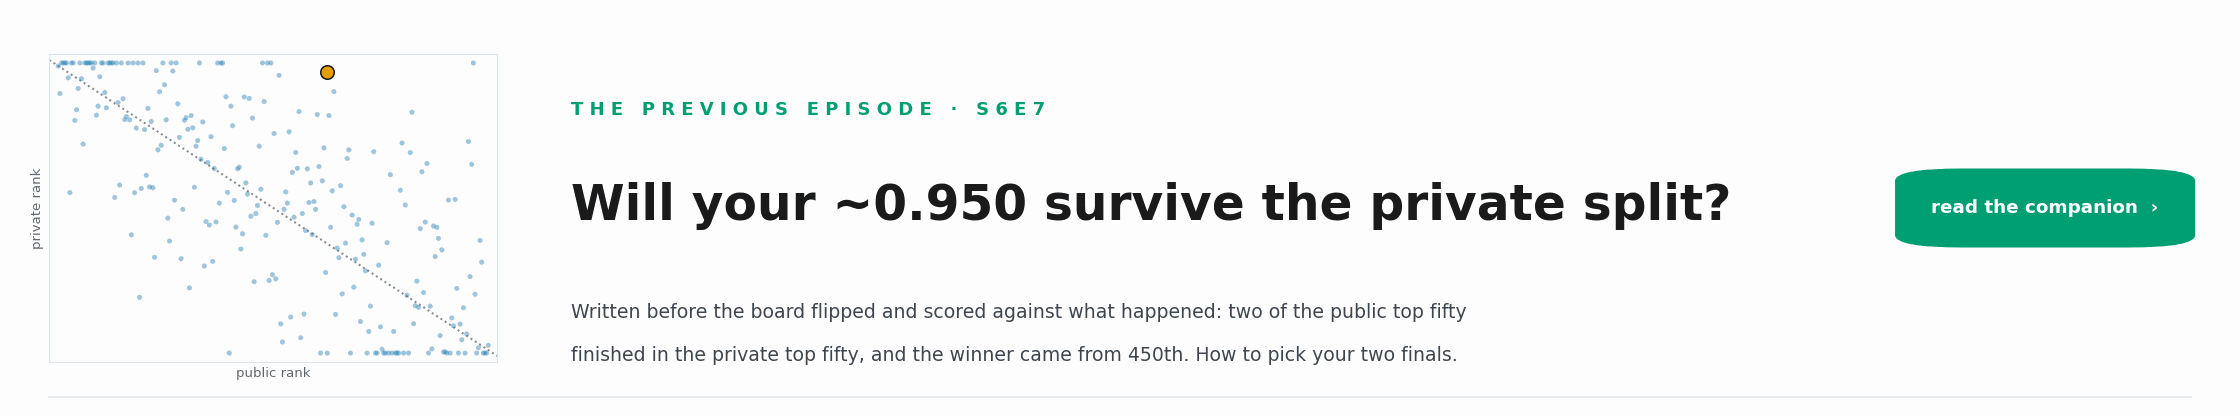</a>

**S6E7** was written before the board flipped and scored afterwards against what happened. Read it for
picking final submissions when the public board is mostly measuring noise, which by section 11 is a
question about how correlated the top entries are, and that episode's were not.

<a href="https://www.kaggle.com/code/georgymamarin/an-almost-exhaustive-stellar-class-eda-final">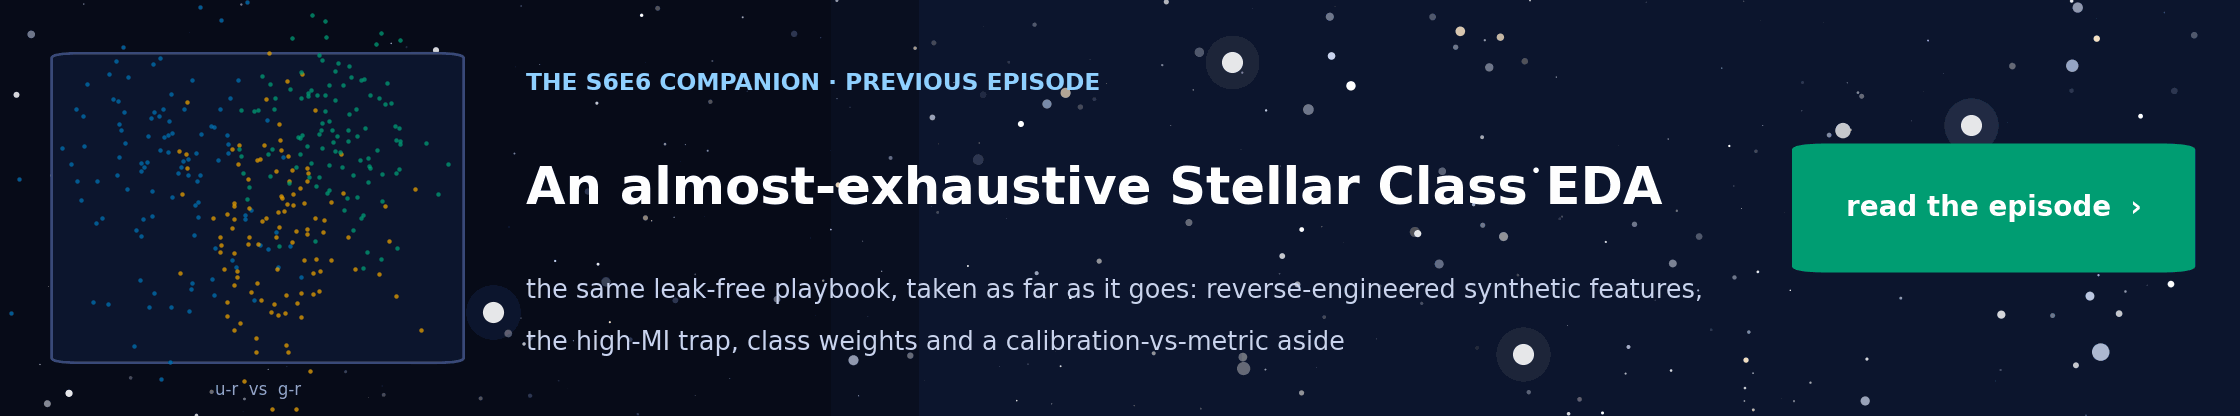</a>

**S6E6** is the long-form version of the leak-free CV method section 8 uses here, with every step
spelled out rather than compressed.

## Credits

Thanks to Kaggle and to Yao Yan, Walter Reade and Elizabeth Park for the series. To ryota517, whose
careful refusal to over-claim the source lineage set the standard section 5 tries to hold to, and who
published the budget constraint first; the account has since been deleted, so the link is gone but the
credit is not. tomasa2 and tamerlanomralinov both published the constraint independently in the days
after, and their notebooks are still up. To Dariush Afshar, whose residual feature is the whole of
section 4c. And to Muhammad Faheem, whose question in that thread is the one 4c ends up answering.

---

**If you fork this, take sections 3 and 4c together.** The conditional control is four lines and works
on any tabular competition; 4c is the reminder that it cannot see a feature assembled from several
columns at once. Either half alone would have misled me, and did. I would like to know whether the
pair changes your read of a feature table somewhere else.

Corrections are welcome, and I will publish them as corrections rather than editing the number and
moving on. That is not a posture: section 4c exists because someone answered a question this notebook
left open, and it went in with their name on it. If you can account for the third of the gap that is
still missing, say so in the comments and the same will happen.